In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.metrics import f1_score, confusion_matrix
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from collections import Counter
import os
import glob
import pyedflib
import yaml
import json
import h5py
import numpy as np
import pandas as pd
import datetime
from tqdm import tqdm
import multiprocessing
from loguru import logger
import warnings
from scipy.signal import butter, filtfilt, resample
import mne
sys.path.append("..")
sys.path.append("../sleepfm")
"""from preprocessing.preprocessing import EDFToHDF5Converter"""
from models.dataset import SetTransformerDataset, collate_fn
from models.models import SetTransformer, SleepEventLSTMClassifier, DiagnosisFinetuneFullLSTMCOXPHWithDemo
from utils import load_config, load_data, save_data, count_parameters
from torch.utils.data import Dataset, DataLoader
import torch
from torch import nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
device = torch.device("cuda")
print(device)

cuda


In [3]:
class EDFToHDF5Converter:
    def __init__(self, root_dir, target_dir, resample_rate=512, num_threads=1, num_files=-1, channels=None):
        self.resample_rate = resample_rate 
        self.root_dir = root_dir
        self.target_dir = target_dir
        self.num_threads = num_threads
        self.num_files = num_files
        self.channels = channels
        self.file_locations = self.get_files() 
        # self.scorers = ['ES','LS','MS']
        self.flow_events = {'Central Apnea': 1, 'Mixed Apnea': 2, 'Obstructive Apnea': 3, 'Hypopnea': 4, 'RERA': 5}
        self.plm_events = {'P-Marker': 1, 'I-Marker': 2, 'LM Body position': 3, 'LM Resp': 4}
        self.arousal_events = {'Autonomic arousals': 1, 'Respiratory Arousal': 2}
        self.sleep_stages = {'Wake': 0, 'Rem': 1, 'N1': 2, 'N2': 3, 'N3': 4, 'Artifact': 5}


    def get_files(self):
        # Search for all '.edf' files within each subdirectory of the root directory
        file_paths = glob.glob(os.path.join(self.root_dir, '**/*.[eE][dD][fF]'), recursive=True)
        file_names = [os.path.basename(path) for path in file_paths]
        return file_paths, file_names
    
    def extract_start_time(self, file_path):
        with open(file_path, 'r') as file:
            lines = [next(file) for _ in range(5)]
            
        for line in lines:
            if line.startswith("Start Time:"):
                return line.split(": ", 1)[1].strip()
        return "Start Time not found"

    def create_signal_from_events(self, df, total_seconds, event_type = None):
        valid_types = {'flow', 'plm', 'arousal','stages'}
        if event_type not in valid_types:
            raise ValueError("event_type must be 'flow', 'plm', or 'arousal'")
        
        total_samples = int(total_seconds * self.resample_rate)
        # make initial array of zeros with length total_sec
        event_array = np.zeros(total_samples)

        # go through each event and mark the corresponding seconds in the array
        for _, row in df.iterrows():
            event_start = int(row['sec_from_start'] * self.resample_rate)
            event_stop = int(row['sec_from_start'] * self.resample_rate + row['dur'] * self.resample_rate)
            if event_type == 'flow':
                event_code = self.flow_events.get(row['event_type'], 0)
            elif event_type == 'plm':
                event_code = self.plm_events.get(row['event_type'], 0)
            elif event_type == 'arousal':
                event_code = self.arousal_events.get(row['event_type'], 0)
            elif event_type == 'stages':
                event_code = self.sleep_stages.get(row['event_type'])
            
            event_array[event_start:event_stop] = event_code
        
        return event_array

    def make_event_dataframe(self, folder, event_type = None):
        valid_types = {'flow', 'plm', 'arousal','stages'}
        if event_type not in valid_types:
            raise ValueError("event_type must be 'flow', 'plm', or 'arousal'")
        if event_type == 'flow':
            flow_file = os.path.join(self.root_dir,folder,'Flow Events.txt')
            df = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
        elif event_type == 'plm':
            flow_file = os.path.join(self.root_dir,folder,'PLM Events.txt')
            df = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
        elif event_type == 'arousal':
            flow_file = os.path.join(self.root_dir,folder,'Autonomic arousals.txt')
            dfAutonomic = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
            flow_file = os.path.join(self.root_dir,folder,'Classification arousals.txt')
            dfClassification = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
            df = pd.concat([dfAutonomic,dfClassification], ignore_index=True)
        elif event_type == 'stages':
            flow_file1 = os.path.join(self.root_dir,folder,'Flow Events.txt')
            start_time = self.extract_start_time(file_path = flow_file1)
            start_time = datetime.datetime.strptime(start_time, "%m/%d/%Y %I:%M:%S %p")
            flow_file = os.path.join(self.root_dir,folder,'Sleep profile.txt')
            df = pd.read_csv(flow_file, delimiter=';',skiprows=7, names=['start', 'event_type']) 
            df['start'] = pd.to_datetime(df['start'], format='%H:%M:%S,%f').dt.time
            df['sec_from_start'] = df['start'].apply(lambda x: (datetime.datetime.combine(datetime.date(1,1,1),x) - datetime.datetime.combine(datetime.date(1,1,1),start_time.time())).total_seconds())
            df['dur'] = 30
            df['event_type'] = df['event_type'].str.strip()
            if df['sec_from_start'].iloc[0] < 0:
                df['dur'][0] = 30 + df['sec_from_start'].iloc[0]
                df['sec_from_start'].iloc[0] = 0
            df.loc[df.sec_from_start < 0, 'sec_from_start'] += 24*60*60
            return df

        # df = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
        if len(df.values) != 0:
            df[['start', 'stop']] = df['start-stop'].str.split('-', expand=True)

            start_time = self.extract_start_time(file_path = flow_file)
            start_time = datetime.datetime.strptime(start_time, "%m/%d/%Y %I:%M:%S %p")

            df['start'] = pd.to_datetime(df['start'], format='%H:%M:%S,%f').dt.time
            df['stop'] = pd.to_datetime(df['stop'], format='%H:%M:%S,%f').dt.time
            df['sec_from_start'] = df['start'].apply(lambda x: (datetime.datetime.combine(datetime.date(1,1,1),x) - datetime.datetime.combine(datetime.date(1,1,1),start_time.time())).total_seconds())
            df['sec_from_stop'] = df['stop'].apply(lambda x: (datetime.datetime.combine(datetime.date(1,1,1),x) - datetime.datetime.combine(datetime.date(1,1,1),start_time.time())).total_seconds())

            df['duration'] = pd.to_numeric(df['duration'])

            df = df[['start', 'stop', 'duration', 'event_type', 'sec_from_start','sec_from_stop']]

            df.loc[df.sec_from_start < 0, 'sec_from_start'] += 24*60*60
            df.loc[df.sec_from_stop < 0, 'sec_from_stop'] += 24*60*60
            df['dur'] = df['sec_from_stop'] - df['sec_from_start']
        else:
            df  = pd.DataFrame(columns = ['start', 'stop', 'duration', 'event_type', 'sec_from_start','sec_from_stop', 'dur'])

        return df

    def convert_events(self, folder,total_seconds,event_type):
        df_events = self.make_event_dataframe(folder, event_type=event_type)
        event_array = self.create_signal_from_events(df=df_events, total_seconds=total_seconds, event_type=event_type)
        return event_array

    def read_edf_old(self, file_path):
        logger.info('reading edf')
        with pyedflib.EdfReader(file_path) as edf:
            signals = [edf.readSignal(i) for i in range(edf.signals_in_file)]
            sample_rates = np.array([edf.getSampleFrequency(i) for i in range(edf.signals_in_file)])
            channel_names = np.array([edf.getLabel(i) for i in range(edf.signals_in_file)])
            # annotations = []#edf.readAnnotations()
        return signals, sample_rates, channel_names
    
    def read_edf(self, file_path):
        logger.info(f'Reading EDF: {os.path.basename(file_path)}')
        
        try:
            # Charger avec filtrage de canaux si spécifié
            if self.channels is not None and len(self.channels) > 0:
                # Vérifier d'abord quels canaux existent
                logger.info(f'Checking available channels...')
                raw_temp = mne.io.read_raw_edf(file_path,include=self.channels, preload=False, verbose=False)
                
                available_channels = [ch for ch in self.channels if ch in raw_temp.ch_names]
                missing_channels = set(self.channels) - set(available_channels)
                
                if missing_channels:
                    logger.warning(f"⚠️  Canaux manquants: {missing_channels}")
                
                if not available_channels:
                    raise ValueError(f"❌ Aucun des canaux spécifiés n'a été trouvé dans {file_path}\n"
                                f"   Canaux demandés: {self.channels}\n"
                                f"   Canaux disponibles: {raw_temp.ch_names}")
                
                logger.info(f'✅ Chargement de {len(available_channels)}/{len(self.channels)} canaux')
                raw = mne.io.read_raw_edf(file_path, include=available_channels, preload=True, verbose=False)
            else:
                # Charger tous les canaux si aucun filtre spécifié
                logger.info('Loading all channels (no filter specified)')
                raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
            
            # Extraire les données
            signals = [raw.get_data(picks=[ch_name])[0] for ch_name in raw.ch_names]
            sample_rates = np.array([raw.info['sfreq'] for _ in raw.ch_names])
            channel_names = np.array(raw.ch_names)
            
            logger.info(f'✅ Loaded {len(channel_names)} channels, {len(signals[0])} samples at {sample_rates[0]} Hz')
            
            return signals, sample_rates, channel_names
            
        except Exception as e:
            logger.error(f"❌ Error reading {file_path}: {str(e)}")
            raise

    def resample_signals_old(self, signals, sample_rates):
        # Vectorization and broadcasting could be applied within the resample function itself
        logger.info('resampling signals')
        resampled_signals = [resample(signal, int(len(signal) * self.resample_rate / rate))
                             for signal, rate in zip(signals, sample_rates)]
        standardized_signals = [(signal - np.mean(signal)) / np.std(signal) for signal in resampled_signals]
        # add signal names as input and filter the spo2 preprocessing as scaled 0 to 1
        return np.stack(standardized_signals)# Using np.stack for proper array dimensions


    def safe_standardize(self, signal):
        mean = np.mean(signal)
        std = np.std(signal)
        
        if std == 0:
            standardized_signal = (signal - mean)
        else:
            standardized_signal = (signal - mean) / std
        
        return standardized_signal
        
    def filter_signal(self, signal, sample_rate):
        print("Filtering signal")
        nyquist_freq = sample_rate / 2
        cutoff = min(self.resample_rate / 2, nyquist_freq)
        normalized_cutoff = cutoff / nyquist_freq
        b, a = butter(4, normalized_cutoff, btype='low', analog=False)
        filtered_signal = filtfilt(b, a, signal)
        return filtered_signal

    def resample_signals(self, signals, sample_rates):
        logger.info('resampling signals')
        resampled_signals = []
        for signal, rate in zip(signals, sample_rates):
            # Calculate the duration of the signal
            duration = len(signal) / rate
            
            # Original time points
            original_time_points = np.linspace(0, duration, num=len(signal), endpoint=False)
            
            # New sample rate and new time points
            new_sample_count = int(duration * self.resample_rate)
            new_time_points = np.linspace(0, duration, num=new_sample_count, endpoint=False)

            #filter signal
            if rate > self.resample_rate:
                signal = self.filter_signal(signal, rate)
            
            # Linear interpolation
            resampled_signal = np.interp(new_time_points, original_time_points, signal)
            
            # Standardize the resampled signal (optional, based on your need)
            # standardized_signal = (resampled_signal - np.mean(resampled_signal)) / np.std(resampled_signal)
            standardized_signal = self.safe_standardize(resampled_signal)
            
            if np.isnan(standardized_signal).any():
                logger.info('Found NaN in the resampled signal.')
                # Handle the NaN case here (e.g., skip or fix the signal)
                continue

            resampled_signals.append(standardized_signal)

        
        return np.stack(resampled_signals)  # Stack for a consistent output format

    def save_to_hdf5(self, signals, channel_names, annotation_signals, annotation_names, file_path):
        logger.info('saving hdf5')
        samples_per_chunk = 5 * 60 * self.resample_rate
        with h5py.File(file_path, 'w') as hdf:
            for signal, name in zip(signals, channel_names):
                dataset_name = self._get_unique_name(hdf, name)
                hdf.create_dataset(dataset_name, data=signal,
                                   dtype='float16', chunks=(samples_per_chunk,), compression="gzip")

            for annot_signal, annot_name in zip(annotation_signals, annotation_names):
                hdf.create_dataset(annot_name, data=annot_signal)

    def _get_unique_name(self, hdf, base_name):
        # Helper method to ensure dataset names are unique
        i = 1
        unique_name = base_name
        while unique_name in hdf:
            unique_name = f"{base_name}_{i}"
            i += 1
        return unique_name

    def get_annotations(self, total_seconds, folder):
        # folder_path = 'C:/Users/45223/OneDrive - Danmarks Tekniske Universitet/PhD/Oliver_triple_scored/triple_scored_studies1/CSA009/ES'
        flow_events = self.convert_events(folder = folder, total_seconds = total_seconds, event_type = 'flow')
        plm_events = self.convert_events( folder = folder, total_seconds = total_seconds, event_type = 'plm')
        arousal_events = self.convert_events( folder = folder, total_seconds = total_seconds, event_type = 'arousal')
        sleep_stages = self.convert_events( folder = folder, total_seconds = total_seconds, event_type = 'stages')

        return flow_events, plm_events, arousal_events, sleep_stages
    
    def convert(self, edf_path, hdf5_path):
        signals, sample_rates, channel_names = self.read_edf(edf_path)
        resampled_signals = self.resample_signals(signals, sample_rates)
        total_duration_seconds = len(signals[0])/sample_rates[0]
        event_signals = []
        event_signal_names = []
        self.save_to_hdf5(resampled_signals, channel_names,event_signals,event_signal_names, hdf5_path)

    def convert_multiprocessing(self, args):
        edf_files = args

        for edf_file in tqdm(edf_files, desc="Converting EDF files"):

            if edf_file.endswith(".edf"):
                replace_str = ".edf"
            elif edf_file.endswith(".EDF"):
                replace_str = ".EDF"
            hdf5_file = os.path.join(self.target_dir, edf_file.split('/')[-1].replace(replace_str, '.hdf5'))

            if os.path.exists(hdf5_file):
                logger.info(f"File already processed: {hdf5_file}")
                continue
            try:
                self.convert(edf_file, hdf5_file)
            except Exception as e:
                warnings.warn(f"Warning: Could not process the file {edf_file}. Error: {str(e)}")
                continue
        return [1]

    def convert_all(self):
        edf_files, edf_names = self.get_files() 
        # folders = self.get_folders()
        for edf_file in tqdm(edf_files, desc="Converting EDF files"):
            # edf_files = [os.path.join(folder, f) for f in os.listdir(os.path.join(self.root_dir,folder)) if f.endswith('.edf')]
            # edf_file = os.path.join(self.root_dir,edf_files[0])
            if edf_file.endswith(".edf"):
                replace_str = ".edf"
            elif edf_file.endswith(".EDF"):
                replace_str = ".EDF"
            hdf5_file = os.path.join(self.target_dir,edf_file.split('/')[-1].replace(replace_str, '.hdf5'))
            # logger.info(edf_file)
            # logger.info(hdf5_file)

            try:
                self.convert(edf_file, hdf5_file)
            except Exception as e:
                warnings.warn(f"Warning: Could not process the file {edf_file}. Error: {str(e)}")
                continue

    def convert_all_multiprocessing(self):
        edf_files, edf_names = self.get_files() 

        if self.num_files != -1:
            edf_files = edf_files[:self.num_files]

        edf_files_chunks = np.array_split(edf_files, self.num_threads)
        tasks = [(edf_files_chunk) for edf_files_chunk in edf_files_chunks]
        with multiprocessing.Pool(self.num_threads) as pool:
            preprocessed_results = [y for x in pool.imap_unordered(self.convert_multiprocessing, tasks) for y in x]

    def convert_with_annot(self, edf_path, hdf5_path, folder):
        signals, sample_rates, channel_names = self.read_edf(edf_path)
        resampled_signals = self.resample_signals(signals, sample_rates)
        total_duration_seconds = len(signals[0])/sample_rates[0]
        event_signals = []
        event_signal_names = []
        for scorer in self.scorers:
            scorer_folder = os.path.join(folder, scorer) 
            flow_events, plm_events, arousal_events, sleep_stages = self.get_annotations(total_seconds = total_duration_seconds, folder = scorer_folder)
            event_signals.extend([flow_events, plm_events, arousal_events, sleep_stages])
            event_signal_names.extend(['flow_events'+scorer, 'plm_events'+scorer, 'arousal_events'+scorer, 'sleep_stages'+scorer])
        self.save_to_hdf5(resampled_signals, channel_names,event_signals,event_signal_names, hdf5_path)

    def convert_all_with_annot(self):
        edf_files, edf_names = self.get_files() 
        folders = self.get_folders()
        for folder in tqdm(folders, desc="Converting EDF files"):
            edf_files = [os.path.join(folder, f) for f in os.listdir(os.path.join(self.root_dir,folder)) if f.lower().endswith('.edf')]
            edf_file = os.path.join(self.root_dir,edf_files[0])
            # header = self.extract_end_time(edf_file)
            # hdf5_file = os.path.join(self.root_dir, edf_file.replace('.edf', '.hdf5'))
            if edf_file.endswith(".edf"):
                replace_str = ".edf"
            elif edf_file.endswith(".EDF"):
                replace_str = ".EDF"
            hdf5_file = os.path.join(self.target_dir,edf_file.split('\\')[-1].replace(replace_str, '.hdf5'))

            # logger.info(hdf5_file)
            self.convert_with_annot(edf_file, hdf5_file, folder)
    def plot_results(self, resampled_signals, channel_names):
        print("plotting resampled_signals")
        num_signals = len(resampled_signals)
        fig, axs = plt.subplots(num_signals, 1, figsize=(15, 3*num_signals), sharex=True)
        samples_to_plot = 10 * self.resample_rate
        sample_to_start = 10 * self.resample_rate
        for i, (signal, name) in enumerate(zip(resampled_signals, channel_names)):
            signal_chunk = signal[sample_to_start:sample_to_start+samples_to_plot]
            axs[i].plot(signal_chunk)
            axs[i].set_title(name)
            axs[i].set_ylabel('Amplitude')
        
        axs[-1].set_xlabel('Samples')
        plt.tight_layout()
        plt.show()

    def plot_first_results(self, resampled_signals, channel_names):
        print("plotting resampled_signals")
        num_signals = len(resampled_signals)
        fig = plt.figure(figsize=(15, 3))
        samples_to_plot = 10 * self.resample_rate
        sample_to_start = 10 * self.resample_rate
        for i, (signal, name) in enumerate(zip(resampled_signals, channel_names)):
            signal_chunk = signal[sample_to_start:sample_to_start+samples_to_plot]
            plt.plot(signal_chunk)
            plt.title(name)
            plt.ylabel('Amplitude')
            break
        
        plt.xlabel('Samples')
        plt.tight_layout()
        plt.show()

    def process_and_plot_single_file(self, edf_path):
        signals, sample_rates, channel_names = self.read_edf(edf_path)
        resampled_signals = self.resample_signals(signals, sample_rates)
        #self.plot_results(resampled_signals, channel_names)
        self.plot_first_results(resampled_signals, channel_names)
    

In [4]:
CHANNEL_GROUPS = {
    "EEG": ["Fp1", "C3", "O1", "C4"],       
    "EOG": ["EOG G", "EOG D"],
    "EMG": ["EMG 1", "EMG 2"],          
    "EKG": ["ECG"],
    "REF": ["A2"],   
    "RESP": ["Thermistance", "Flow",]                   
}
CHANNEL_OI = sorted({ch for grp in CHANNEL_GROUPS.values() for ch in grp})

CATEGORY_MAPPING = {
    "EEG": "BAS",
    "EOG": "BAS",
    "REF": "BAS",
    "ECG": "EKG",
    "EMG": "EMG",
    "RESP": "RESP",
    "EKG": "EKG"
}
CHANNEL_GROUPS_FOR_MODEL = {'BAS': [], 'EKG': [], 'RESP': [], 'EMG': []}

for category, channels in CHANNEL_GROUPS.items():
    model_category = CATEGORY_MAPPING.get(category, 'BAS')
    CHANNEL_GROUPS_FOR_MODEL[model_category].extend(channels)
print(CHANNEL_GROUPS_FOR_MODEL)

{'BAS': ['Fp1', 'C3', 'O1', 'C4', 'EOG G', 'EOG D', 'A2'], 'EKG': ['ECG'], 'RESP': ['Thermistance', 'Flow'], 'EMG': ['EMG 1', 'EMG 2']}


In [5]:
import os
import glob 
from tqdm import tqdm
import time

edf_folder = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_more"
output_folder = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_more"

os.makedirs(output_folder, exist_ok=True)

def edf_to_hdf5(input_folder, output_folder):
    # Trouver tous les EDF
    edf_files = glob.glob(os.path.join(input_folder, "**/*.edf"), recursive=True)
    edf_files += glob.glob(os.path.join(input_folder, "**/*.EDF"), recursive=True)
    
    print(f"\n📁 {len(edf_files)} fichiers EDF trouvés\n")
    
    converter = EDFToHDF5Converter(
        root_dir=input_folder,
        target_dir=output_folder,
        resample_rate=128,
        channels=CHANNEL_OI
    )
    
    # Convertir avec barre de progression
    success = 0
    errors = 0
    skipped = 0
    
    for edf_path in tqdm(edf_files, desc="🔄 Conversion", unit="fichier"):
        basename = os.path.basename(edf_path).replace('.edf', '').replace('.EDF', '')
        hdf5_path = os.path.join(output_folder, f"{basename}.hdf5")
        
        # Skip si existe déjà
        if os.path.exists(hdf5_path):
            skipped += 1
            tqdm.write(f"⏭️  {basename} (déjà converti)")
            continue
        
        try:
            start = time.time()
            converter.convert(edf_path, hdf5_path)
            duration = time.time() - start
            success += 1
            tqdm.write(f"✅ {basename} ({duration:.1f}s)")
        except Exception as e:
            errors += 1
            tqdm.write(f"❌ {basename}: {str(e)[:50]}")
        os.remove(edf_path)
    
    # Résumé
    print(f"\n{'='*50}")
    print(f"✅ Réussis:  {success}")
    print(f"⏭️  Ignorés:  {skipped}")
    print(f"❌ Erreurs:  {errors}")
    print(f"{'='*50}")


def txt_to_csv(input_folder, output_folder):
    
    os.makedirs(output_folder, exist_ok=True)
    
    STAGE_TO_NUMBER = {
        'W': 0,
        '1': 1,
        '2': 2,
        '3': 3,
        '4': 3,
        'R': 4
    }
    
    STAGE_NAMES = {
        0: "Wake",
        1: "Stage 1",
        2: "Stage 2",
        3: "Stage 3",
        4: "REM"
    }
    
    txt_files = glob.glob(os.path.join(input_folder, "*.txt"))
    txt_files += glob.glob(os.path.join(input_folder, "*.TXT"))
    
    print(f"\n📁 {len(txt_files)} fichiers TXT trouvés\n")
    
    if len(txt_files) == 0:
        return
    
    success = 0
    errors = 0
    
    for txt_file in tqdm(txt_files, desc="🔄 Conversion TXT→CSV", unit="fichier"):
        try:
            # Nom du fichier original
            original_basename = os.path.basename(txt_file).replace('.txt', '').replace('.TXT', '')
            
            # Enlever le préfixe "PSG4_Hypnogram_Export_"
            if original_basename.startswith("PSG4_Hypnogram_Export_"):
                new_basename = original_basename.replace("PSG4_Hypnogram_Export_", "")
            else:
                new_basename = original_basename
            
            # Chemin du CSV de sortie
            csv_file = os.path.join(output_folder, f"{new_basename}.csv")
            
            # Charger les stages (30s par ligne)
            stages_30s = np.loadtxt(txt_file, dtype=str)
            
            # Répéter chaque stage 6 fois (pour 6 epochs de 5s)
            stages_5s = np.repeat(stages_30s, 6)
            n_epochs = len(stages_5s)
            
            # Créer les timestamps
            starts = np.arange(0, n_epochs * 5, 5)
            stops = starts + 5
            
            # Créer le DataFrame
            df = pd.DataFrame({
                'Start': starts,
                'Stop': stops,
                'StageName': [STAGE_NAMES.get(STAGE_TO_NUMBER.get(s, -1), "Unknown") for s in stages_5s],
                'StageNumber': [STAGE_TO_NUMBER.get(s, -1) for s in stages_5s],
                'EmbeddingNumber': np.arange(n_epochs)
            })
            
            # Sauvegarder
            df.to_csv(csv_file, index=False)
            
            success += 1
            tqdm.write(f"✅ {original_basename} → {new_basename}.csv")
            os.remove(txt_file)
        except Exception as e:
            errors += 1
            tqdm.write(f"❌ {os.path.basename(txt_file)}: {str(e)[:50]}")

    print(f"✅ Convertis: {success}")
    print(f"❌ Erreurs:   {errors}")
    print(f"📂 Dossier de sortie: {output_folder}")

# ========== UTILISATION ==========
input_folder = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_more"
output_folder = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_more"

txt_to_csv(input_folder, output_folder)
edf_to_hdf5(edf_folder, output_folder)



📁 0 fichiers TXT trouvés


📁 0 fichiers EDF trouvés



🔄 Conversion: 0fichier [00:00, ?fichier/s]


✅ Réussis:  0
⏭️  Ignorés:  0
❌ Erreurs:  0


In [ ]:
from glob import glob
model_path = "../sleepfm/checkpoints/model_base"
channel_groups_path = "../sleepfm/configs/channel_groups.json"
config_path = os.path.join(model_path, "config.json")

config = load_config(config_path)

def create_embedding_and_filtering(config,hdf5_paths,collate_fn,output_dir, output_5min_agg_dir, checkpoint=True, converting_edf=True):
    
    edf = glob(os.path.join(hdf5_paths, "*.edf"))
    txt = glob(os.path.join(hdf5_paths, "*.txt"))
    if converting_edf and len(edf) > 0:
        edf_to_hdf5(input_folder=hdf5_paths, output_folder=hdf5_paths)
    if len(txt) > 0:
        txt_to_csv(input_folder=hdf5_paths, output_folder=hdf5_paths)
        
    modality_types = config["modality_types"]
    in_channels = config["in_channels"]
    patch_size = config["patch_size"]
    embed_dim = config["embed_dim"]
    num_heads = config["num_heads"]
    num_layers = config["num_layers"]
    pooling_head = config["pooling_head"]
    dropout = 0.0

    print(f"CUDA disponible: {torch.cuda.is_available()}")
    print(f"Version PyTorch: {torch.__version__}")

    model_class = getattr(sys.modules[__name__], config['model'])
    model = model_class(in_channels, patch_size, embed_dim, num_heads, num_layers, pooling_head=pooling_head, dropout=dropout)

    device = torch.device("cuda")
    print(device)

    if device.type == "cuda":
        model = torch.nn.DataParallel(model)

    model.to(device)
    if checkpoint:
        checkpoint = torch.load(os.path.join(model_path, "best.pt"))
        model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    hdf5_files = glob(os.path.join(hdf5_paths, "*.hdf5"))
    dataset = SetTransformerDataset(config, CHANNEL_GROUPS_FOR_MODEL , hdf5_paths=hdf5_files, split="test")
    dataloader = torch.utils.data.DataLoader(dataset, 
                                                batch_size=16, 
                                                num_workers=1, 
                                                shuffle=False, 
                                                collate_fn=collate_fn)

    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(output_5min_agg_dir, exist_ok=True)
    
    with torch.no_grad():
        with tqdm(total=len(dataloader)) as pbar:
            for batch in dataloader:
                batch_data, mask_list, file_paths, dset_names_list, chunk_starts = batch
                (bas, resp, ekg, emg) = batch_data
                (mask_bas, mask_resp, mask_ekg, mask_emg) = mask_list

                bas = bas.to(device, dtype=torch.float)
                resp = resp.to(device, dtype=torch.float)
                ekg = ekg.to(device, dtype=torch.float)
                emg = emg.to(device, dtype=torch.float)

                mask_bas = mask_bas.to(device, dtype=torch.bool)
                mask_resp = mask_resp.to(device, dtype=torch.bool)
                mask_ekg = mask_ekg.to(device, dtype=torch.bool)
                mask_emg = mask_emg.to(device, dtype=torch.bool)

                embeddings = [
                    model(bas, mask_bas),
                    model(resp, mask_resp),
                    model(ekg, mask_ekg),
                    model(emg, mask_emg),
                ]
                # Model gives two kinds of embeddings. Granular 5 second-level embeddings and aggregated 5 minute-level embeddings. We save both of them below. 

                embeddings_new = [e[0].unsqueeze(1) for e in embeddings]

                for i in range(len(file_paths)):
                    file_path = file_paths[i]
                    chunk_start = chunk_starts[i]
                    subject_id = os.path.basename(file_path).split('.')[0]
                    output_5min_agg_path = os.path.join(output_5min_agg_dir, f"{subject_id}.hdf5")

                    with h5py.File(output_5min_agg_path, 'a') as hdf5_file:
                        for modality_idx, modality_type in enumerate(config["modality_types"]):
                            if modality_type in hdf5_file:
                                dset = hdf5_file[modality_type]
                                chunk_start_correct = chunk_start // (embed_dim * 5 * 60)
                                chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]
                                if dset.shape[0] < chunk_end:
                                    dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])
                                dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()
                            else:
                                hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])

                embeddings_new = [e[1] for e in embeddings]

                for i in range(len(file_paths)):
                    file_path = file_paths[i]
                    chunk_start = chunk_starts[i]
                    subject_id = os.path.basename(file_path).split('.')[0]
                    output_path = os.path.join(output_dir, f"{subject_id}.hdf5")

                    with h5py.File(output_path, 'a') as hdf5_file:
                        for modality_idx, modality_type in enumerate(config["modality_types"]):
                            if modality_type in hdf5_file:
                                dset = hdf5_file[modality_type]
                                chunk_start_correct = chunk_start // (embed_dim * 5)
                                chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]
                                if dset.shape[0] < chunk_end:
                                    dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])
                                dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()
                            else:
                                hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])
                pbar.update()

hdf5_paths = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_more"
output = os.path.join(hdf5_paths, "train_emb_hazard_clean")
output_5min_agg = os.path.join(hdf5_paths, "train_emb__hazard_5min_agg_clean")
model_path = "../sleepfm/checkpoints/model_base"
channel_groups_path = "../sleepfm/configs/channel_groups.json"
config_path = os.path.join(model_path, "config.json")
config = load_config(config_path) 

"""create_embedding(config, hdf5_paths, collate_fn, output, output_5min_agg,checkpoint = False)   """            

'create_embedding(config, hdf5_paths, collate_fn, output, output_5min_agg,checkpoint = False)   '

In [7]:
output = os.path.join(hdf5_paths, "train_emb_clean_more")
output_5min_agg = os.path.join(hdf5_paths, "train_emb_5min_agg_clean_more")
create_embedding_and_filtering(config, hdf5_paths, collate_fn, output, output_5min_agg, checkpoint = True)


CUDA disponible: True
Version PyTorch: 2.5.1+cu121
cuda


c:\Users\gabri\anaconda3\envs\sleepfm_env\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\gabri\AppData\Local\Temp\ipykernel_50880\446752236.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `w

In [8]:
from einops import rearrange

class PositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.encoding = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
    
    def forward(self, x):
        B, S, E = x.shape
        return x + self.encoding[:, :S, :]

class AttentionPooling(nn.Module):
    """Pooling spatial avec attention"""
    def __init__(self, embed_dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.transformer_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.query = nn.Parameter(torch.randn(1, 1, embed_dim))
        
    def forward(self, x, mask=None):
        # x: (B, C, E), mask: (B, C)
        B = x.size(0)
        query = self.query.expand(B, -1, -1)  # (B, 1, E)
        
        # Concat query with input
        x = torch.cat([query, x], dim=1)  # (B, 1+C, E)
        
        if mask is not None:
            # Add False for query position
            query_mask = torch.zeros(B, 1, dtype=torch.bool, device=mask.device)
            mask = torch.cat([query_mask, mask], dim=1)
        
        x = self.transformer_layer(x, src_key_padding_mask=mask)
        return x[:, 0, :]  # Return query output

class MultiScaleTemporalBlock(nn.Module):
    """
    Capture des patterns temporels à plusieurs échelles:
    - 5-10s: Micro-éveils, mouvements oculaires rapides
    - 30s-1min: Transitions entre stades
    - 2-5min: Cycles de sommeil
    """
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        
        # Échelle courte (local): Conv1D avec petit kernel
        self.short_scale = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=3, padding=1, groups=embed_dim),
            nn.GELU(),
            nn.Conv1d(embed_dim, embed_dim, kernel_size=1),
            nn.Dropout(dropout)
        )
        
        # Échelle moyenne: Conv1D avec kernel moyen
        self.medium_scale = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=7, padding=3, groups=embed_dim),
            nn.GELU(),
            nn.Conv1d(embed_dim, embed_dim, kernel_size=1),
            nn.Dropout(dropout)
        )
        
        # Échelle longue: Attention
        self.long_scale = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        
        # Fusion des échelles
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim * 3, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        
        self.norm = nn.LayerNorm(embed_dim)
        
    def forward(self, x, mask=None):
        # x: (B, S, E)
        residual = x
        
        # Short scale
        x_short = self.short_scale(x.transpose(1, 2)).transpose(1, 2)
        
        # Medium scale
        x_medium = self.medium_scale(x.transpose(1, 2)).transpose(1, 2)
        
        # Long scale avec attention
        if mask is not None:
            x_long, _ = self.long_scale(x, x, x, key_padding_mask=mask)
        else:
            x_long, _ = self.long_scale(x, x, x)
        
        # Fusion
        x_fused = torch.cat([x_short, x_medium, x_long], dim=-1)
        x_out = self.fusion(x_fused)
        
        # Residual connection
        x_out = self.norm(x_out + residual)
        
        return x_out

class SleepStagingModel(nn.Module):
    def __init__(
        self,
        embed_dim=256,
        num_heads=8,
        num_layers=5,
        num_classes=5,
        pooling_head=4,
        dropout=0.1,
        max_seq_length=2160,
    ):
        super().__init__()
        
        if max_seq_length is None:
            max_seq_length = 20000
            
        self.spatial_pooling = AttentionPooling(embed_dim, num_heads=pooling_head, dropout=dropout)
        self.positional_encoding = PositionalEncoding(max_seq_length, embed_dim)
        self.input_norm = nn.LayerNorm(embed_dim)
        
        # Multi-scale blocks
        self.temporal_blocks = nn.ModuleList([
            MultiScaleTemporalBlock(embed_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])
        
        # Simple classifier
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.LayerNorm(embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes)
        )
        
    def forward(self, x, mask):
        B, C, S, E = x.shape
        
        # Spatial pooling
        x = rearrange(x, 'b c s e -> (b s) c e')
        mask_spatial = rearrange(mask[:, :, 0].unsqueeze(1).expand(-1, S, -1), 'b s c -> (b s) c').bool()
        x = self.spatial_pooling(x, mask_spatial)
        x = x.view(B, S, E)
        
        # Temporal modeling
        x = self.positional_encoding(x)
        x = self.input_norm(x)
        
        mask_temporal = mask[:, 0, :].bool()
        for block in self.temporal_blocks:
            x = block(x, mask_temporal)
        
        # Classification
        logits = self.classifier(x)
        
        return logits, mask_temporal

In [9]:
def load_data(file_path):
    with open(file_path, 'r') as f:
        if file_path.endswith('.yaml'):
            return yaml.safe_load(f)

config_path = "test.yaml"
config_ent = load_data(config_path)
print(" Config chargée depuis test.yaml")
print(f" Model: {config_ent.get('model', 'N/A')}")
print(f" Model params: {config_ent.get('model_params', {})}")

sleep_staging_model = SleepStagingModel(**config_ent['model_params'])
sleep_staging_model = sleep_staging_model.to(device)
sleep_staging_model = nn.DataParallel(sleep_staging_model)

print(f"\n Modèle créé : {type(sleep_staging_model).__name__}")
print(f"Nombre de paramètres : {sum(p.numel() for p in sleep_staging_model.parameters()):,}")

 Config chargée depuis test.yaml
 Model: SleepStagingModel
 Model params: {'embed_dim': 128, 'num_heads': 2, 'num_layers': 4, 'num_classes': 5, 'pooling_head': 8, 'dropout': 0.2, 'max_seq_length': 2160}

 Modèle créé : DataParallel
Nombre de paramètres : 1,480,197


In [10]:
class SleepEventClassificationDataset(Dataset):
    def __init__(
        self,
        config,
        channel_groups,
        hdf5_paths,
        label_files,
        split="train",
    ):
        self.config = config
        self.max_channels = self.config["max_channels"]
        self.context = int(self.config["context"])
        self.channel_like = self.config["channel_like"]

        self.max_seq_len = config["model_params"]["max_seq_length"]

        # --- Build label lookup: {study_id: label_csv_path} ---
        # study_id = filename without extension, e.g. "SSC_12345"
        labels_dict = {
            os.path.basename(p).rsplit(".", 1)[0]: p
            for p in label_files
            if os.path.exists(p)
        }

        # --- Filter to HDF5s that exist and have a matching label file ---
        hdf5_paths = [p for p in hdf5_paths if os.path.exists(p)]
        hdf5_paths = [
            p for p in hdf5_paths
            if os.path.basename(p).rsplit(".", 1)[0] in labels_dict
        ]

        if config.get("max_files"):
            hdf5_paths = hdf5_paths[: config["max_files"]]

        self.hdf5_paths = hdf5_paths
        self.labels_dict = labels_dict

        # --- Build index map ---
        # Each item is (hdf5_path, label_path, start_index)
        
        if self.context == -1:
            self.index_map = [
                (p, labels_dict[os.path.basename(p).rsplit(".", 1)[0]], -1)
                for p in self.hdf5_paths
            ]
        else:
            self.index_map = []
            loop = tqdm(self.hdf5_paths, total=len(self.hdf5_paths), desc=f"Indexing {split} data")
            for hdf5_file_path in loop:
                file_prefix = os.path.basename(hdf5_file_path).rsplit(".", 1)[0]
                label_path = labels_dict[file_prefix]

                with h5py.File(hdf5_file_path, "r") as hf:
                    dset_names = list(hf.keys())
                    if len(dset_names) == 0:
                        continue

                    # Use first dataset to define length (same as your original behavior)
                    first_name = dset_names[0]
                    dataset_length = hf[first_name].shape[0]

                for i in range(0, dataset_length, self.context):
                    self.index_map.append((hdf5_file_path, label_path, i))

        # If you have logger, keep; otherwise you can remove these.
        # logger.info(f"Number of files in {split} set: {len(self.hdf5_paths)}")
        # logger.info(f"Number of files to be processed in {split} set: {len(self.index_map)}")

        self.total_len = len(self.index_map)

    def __len__(self):
        return self.total_len

    def get_index_map(self):
        return self.index_map

    def __getitem__(self, idx):
        hdf5_path, label_path, start_index = self.index_map[idx]

        
        labels_df = pd.read_csv(label_path)
        labels_df["StageNumber"] = labels_df["StageNumber"].replace(-1, 0)

        y_data = labels_df["StageNumber"].to_numpy()
        if self.context != -1:
            y_data = y_data[start_index : start_index + self.context]

        x_data = []
        with h5py.File(hdf5_path, "r") as hf:
            dset_names = list(hf.keys())
            for dataset_name in dset_names:
                if dataset_name in self.channel_like:
                    if self.context == -1:
                        x_data.append(hf[dataset_name][:])
                    else:
                        x_data.append(hf[dataset_name][start_index : start_index + self.context])

        if not x_data:
            # Skip this data point if x_data is empty
            return self.__getitem__((idx + 1) % self.total_len)

        x_data = np.array(x_data)  # (C, T, F) assuming each channel returns (T, F)
        x_data = torch.tensor(x_data, dtype=torch.float32)
        y_data = torch.tensor(y_data, dtype=torch.float32)

        min_length = min(x_data.shape[1], len(y_data))
        x_data = x_data[:, :min_length, :]
        y_data = y_data[:min_length]

        return x_data, y_data, self.max_channels, self.max_seq_len, hdf5_path
    
def sleep_event_finetune_full_collate_fn(batch):
    x_data, y_data, max_channels_list, max_seq_len_list, hdf5_path_list = zip(*batch)

    num_channels = max(max_channels_list)

    max_seq_len_temp = max([item.size(1) for item in x_data])
    # Determine the max sequence length for padding
    if max_seq_len_list[0] is None:
        max_seq_len = max_seq_len_temp
    else:
        max_seq_len = min(max_seq_len_temp, max_seq_len_list[0])

    padded_x_data = []
    padded_y_data = []
    padded_mask = []

    for x_item, y_item in zip(x_data, y_data):

        # first non-zero index of y_data
        #print(y_item.shape)
        tgt_sleep_no_sleep = np.where(y_item > 0, 1, 0)
        moving_avg_tgt_sleep_no_sleep = np.convolve(tgt_sleep_no_sleep, np.ones(1080)/1080, mode='valid')
        try:
            first_non_zero_index = np.where(moving_avg_tgt_sleep_no_sleep > 0.5)[0][0]
        except IndexError:
            first_non_zero_index = 0



        #non_zero_indices = (y_item != 0).nonzero(as_tuple=True)[0]
        #first_non_zero_index = non_zero_indices[0].item() - 20
        if first_non_zero_index < 0:
            first_non_zero_index = 0

        #first_non_zero_index = 0

        #print(f"First non-zero index of y_data: {first_non_zero_index}")
        # Get the shape of x_item
        c, s, e = x_item.size()
        c = min(c, num_channels)
        s = min(s, max_seq_len + first_non_zero_index)  # Ensure the sequence length doesn't exceed max_seq_len

        # Create a padded tensor and a mask tensor for x_data
        padded_x_item = torch.zeros((num_channels, max_seq_len, e))
        mask = torch.ones((num_channels, max_seq_len))

        # Copy the actual data to the padded tensor and set the mask for real data
        #print(f"Shape of x_item: {x_item[:c, first_non_zero_index:s, :e].shape}")
        padded_x_item[:c, :s-first_non_zero_index, :e] = x_item[:c, first_non_zero_index:s, :e]
        mask[:c, :s-first_non_zero_index] = 0  # 0 for real data, 1 for padding

        # Pad y_data with zeros to match max_seq_len
        padded_y_item = torch.zeros(max_seq_len)
        padded_y_item[:s-first_non_zero_index] = y_item[first_non_zero_index:s]

        # Append padded items to lists
        padded_x_data.append(padded_x_item)
        padded_y_data.append(padded_y_item)
        padded_mask.append(mask)

    # Stack all tensors into a batch
    x_data = torch.stack(padded_x_data)
    y_data = torch.stack(padded_y_data)
    padded_mask = torch.stack(padded_mask)

    '''
    for y_data_mini in y_data:
        unique_labels = torch.unique(y_data_mini)
        print(f"Unique labels in batch: {unique_labels}")
    '''

    return x_data, y_data, padded_mask, hdf5_path_list

def sleep_collate_easy(batch):
     # Unpack batch
    x_data, y_data, max_channels_list, max_seq_len_list, hdf5_path_list = zip(*batch)

    # Déterminer les dimensions max
    num_channels = max(max_channels_list)
    max_seq_len_temp = max([item.size(1) for item in x_data])
    
    if max_seq_len_list[0] is None:
        max_seq_len = max_seq_len_temp
    else:
        max_seq_len = min(max_seq_len_temp, max_seq_len_list[0])

    padded_x_data = []
    padded_y_data = []
    padded_mask = []

    # Padding pour chaque élément du batch
    for x_item, y_item in zip(x_data, y_data):
        
        c, s, e = x_item.size()  # (canaux, séquence, features)
        c = min(c, num_channels)
        s = min(s, max_seq_len)

        # Créer tenseurs paddés
        padded_x_item = torch.zeros((num_channels, max_seq_len, e))
        mask = torch.ones((num_channels, max_seq_len))
        padded_y_item = torch.zeros(max_seq_len)

        # Copier les données réelles
        padded_x_item[:c, :s, :e] = x_item[:c, :s, :e]
        mask[:c, :s] = 0  # 0 = vraies données, 1 = padding
        padded_y_item[:s] = y_item[:s]

        # Ajouter aux listes
        padded_x_data.append(padded_x_item)
        padded_y_data.append(padded_y_item)
        padded_mask.append(mask)

    # Empiler en batch
    x_data = torch.stack(padded_x_data)      # (batch, channels, seq, features)
    y_data = torch.stack(padded_y_data)      # (batch, seq)
    padded_mask = torch.stack(padded_mask)   # (batch, channels, seq)

    return x_data, y_data, padded_mask, hdf5_path_list


In [11]:
class MaskedCrossEntropyLoss(nn.Module):
        def __init__(self, class_weights=None):
            super().__init__()
            self.class_weights = class_weights
            self.ce_loss = nn.CrossEntropyLoss(weight=class_weights, reduction='none')
        
        def forward(self, logits, targets, mask):
            """
            Args:
                logits: (B, S, C) - prédictions
                targets: (B, S) - labels
                mask: (B, S) - masque (True = ignorer, False = garder)
            """
            B, S, C = logits.shape
            
            # Flatten
            logits_flat = logits.reshape(-1, C)
            targets_flat = targets.reshape(-1).long()
            mask_flat = mask.reshape(-1)
            
            # Calculer la loss pour tous les éléments
            loss = self.ce_loss(logits_flat, targets_flat)
            
            # ⚠️ CORRECTION : Convertir le masque booléen en float
            # Si mask = True → ignorer (multiplier par 0)
            # Si mask = False → garder (multiplier par 1)
            if mask_flat.dtype == torch.bool:
                # Inverser : True → 0.0, False → 1.0
                mask_flat = (~mask_flat).float()
            else:
                # Si déjà float : 1 = ignorer, 0 = garder
                mask_flat = 1.0 - mask_flat
            
            # Appliquer le masque
            loss = loss * mask_flat
            
            # Moyenne sur les éléments valides
            num_valid = mask_flat.sum()
            if num_valid > 0:
                loss = loss.sum() / num_valid
            else:
                loss = loss.sum()
            
            return loss

criterion = MaskedCrossEntropyLoss(class_weights=None).to(device)

In [12]:

def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    accumulation_steps = config.get('accumulation_steps', 1)
    gradient_clip = config.get('gradient_clip', 1.0)
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1} [Train]", leave=False)
    optimizer.zero_grad()

    for batch_idx, (x_batch, y_batch, mask_batch, paths) in enumerate(pbar):

        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        mask_batch = mask_batch.to(device, non_blocking=True)
        outputs = model(x_batch, mask_batch)
        if isinstance(outputs, tuple):
            if len(outputs) == 3:
                logits, _, mask_temporal = outputs
            else:
                logits, mask_temporal = outputs
        else:
            logits = outputs
            mask_temporal = mask_batch[:, 0, :]
        loss = criterion(logits, y_batch, mask_temporal)
        loss = loss / accumulation_steps
        loss.backward()
        if (batch_idx + 1) % accumulation_steps == 0:
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            optimizer.step()
            optimizer.zero_grad()
        total_loss += loss.item() * accumulation_steps
        
        with torch.no_grad():
            preds = torch.argmax(logits, dim=-1)
            mask_flat = mask_temporal.cpu().numpy().flatten()
            preds_flat = preds.cpu().numpy().flatten()
            labels_flat = y_batch.cpu().numpy().flatten()
            
            valid_idx = mask_flat == 0
            all_preds.extend(preds_flat[valid_idx])
            all_labels.extend(labels_flat[valid_idx])
        pbar.set_postfix({'loss': f"{loss.item() * accumulation_steps:.4f}"})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    return avg_loss, accuracy, f1_macro, f1_weighted

def validate(model, dataloader, criterion, device, epoch):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1} [Val]", leave=False)
        
        for x_batch, y_batch, mask_batch, paths in pbar:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            mask_batch = mask_batch.to(device, non_blocking=True)
            
            outputs = model(x_batch, mask_batch)
            
            if isinstance(outputs, tuple):
                if len(outputs) == 3:
                    logits, _, mask_temporal = outputs
                else:
                    logits, mask_temporal = outputs
            else:
                logits = outputs
                mask_temporal = mask_batch[:, 0, :]
            
            loss = criterion(logits, y_batch, mask_temporal)
            total_loss += loss.item()
            
            preds = torch.argmax(logits, dim=-1)
            mask_flat = mask_temporal.cpu().numpy().flatten()
            preds_flat = preds.cpu().numpy().flatten()
            labels_flat = y_batch.cpu().numpy().flatten()
            
            valid_idx = mask_flat == 0
            all_preds.extend(preds_flat[valid_idx])
            all_labels.extend(labels_flat[valid_idx])
            
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    return avg_loss, accuracy, f1_macro, f1_weighted, all_preds, all_labels



In [13]:
def plotter(history, log_dir, best_val_f1):
    print(f"\n{'='*60}")
    print(f"✅ ENTRAÎNEMENT TERMINÉ")
    print(f"{'='*60}")

    print(f"\n📈 Meilleur résultat:")
    print(f"   Val F1-Macro: {best_val_f1:.4f}")

    print(f"\n📊 Progression:")
    print(f"   Epoch   1: Train Acc={history['train_acc'][0]:.3f}, Val Acc={history['val_acc'][0]:.3f}")
    print(f"   Epoch  50: Train Acc={history['train_acc'][49]:.3f}, Val Acc={history['val_acc'][49]:.3f}") if len(history['train_acc']) >= 50 else None
    print(f"   Epoch 100: Train Acc={history['train_acc'][-1]:.3f}, Val Acc={history['val_acc'][-1]:.3f}")
        
    import matplotlib.pyplot as plt

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
    ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss over epochs')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
    ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy over epochs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(log_dir, 'overfit_curves.png'), dpi=150)
    print(f"\n✅ Graphiques sauvegardés: {os.path.join(log_dir, 'overfit_curves.png')}")
    plt.show()

    # ============================================================
    # DIAGNOSTIC
    # ============================================================

    print(f"\n🔍 DIAGNOSTIC:")

    final_train_acc = history['train_acc'][-1]
    final_val_acc = history['val_acc'][-1]

    if final_train_acc > 0.95 and final_val_acc > 0.95:
        print(f"   ✅✅✅ EXCELLENT ! Le modèle peut overfitter")
        print(f"       → Le modèle FONCTIONNE et peut apprendre")
        print(f"       → Le problème vient de l'alignement ou du dataset complet")
    elif final_train_acc > 0.70:
        print(f"   ✅ BON ! Le modèle apprend")
        print(f"       → Peut-être besoin de plus d'epochs ou LR plus élevé")
    elif final_train_acc > 0.40:
        print(f"   ⚠️ MOYEN. Le modèle apprend lentement")
        print(f"       → Vérifier le format d'entrée ou l'architecture")
    else:
        print(f"   ❌ PROBLÈME ! Le modèle n'apprend pas")
        print(f"       → Format d'entrée incorrect")
        print(f"       → Poids frozen")
        print(f"       → Bug dans le forward pass")

    print(f"\n{'='*60}")

In [ ]:
from glob import glob
checkpoint_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\save_10_data\\checkpoints\\best.pth"
base_data_path_emb = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_more\\train_emb_clean_more"
base_data_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_more"
base_save_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\save_10_data"

def training(config_ent, sleep_staging_model, base_data_path_emb, base_data_path, base_save_path, train_one_epoch= train_one_epoch, validate=validate, criterion= criterion, checkpoint = False, checkpoint_path = None, plotter_bool=True):

    if checkpoint and checkpoint_path is not None:
        if os.path.exists(checkpoint_path):
            print(f"\n Chargement du checkpoint: {checkpoint_path}")
            
            checkpoint = torch.load(checkpoint_path, map_location=device)
    
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint
    
        new_state_dict = {}
        for k, v in state_dict.items():
            new_key = k.replace('module.', '')
            new_state_dict[new_key] = v
        
        # Charger (strict=False car votre architecture peut différer)
        sleep_staging_model.load_state_dict(new_state_dict, strict=False)
        print(" Checkpoint chargé")
    else:
        print(f"\n  Aucun checkpoint trouvé à {checkpoint_path}")
        print("   Le modèle sera entraîné depuis zéro")
    checkpoint_dir = os.path.join(base_save_path, "checkpoints")
    log_dir = os.path.join(base_save_path, "logs")
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(log_dir, exist_ok=True)

    # Sauvegarder la config
    with open(os.path.join(checkpoint_dir, "config.json"), 'w') as f:
        json.dump(config_ent, f, indent=4)

    print(f" Checkpoints: {checkpoint_dir}")
    print(f" Logs: {log_dir}")
    hdf5_files = glob(os.path.join(base_data_path_emb, "*.hdf5"))

    file_pairs = []

    for hdf5_path in hdf5_files:
        # Extraire le nom de base (ex: C1_012_PSG1)
        hdf5_basename = os.path.basename(hdf5_path).replace('.hdf5', '')

        csv_pattern = f"{hdf5_basename}.csv"
        csv_path = os.path.join(base_data_path, csv_pattern)
        if os.path.exists(csv_path):
            file_pairs.append((hdf5_path, csv_path))
        else:
            print(f"CSV manquant pour: {hdf5_basename}")
            print(f"Cherché: {csv_pattern}")

    print(f"\n Total de paires HDF5-CSV: {len(file_pairs)}")

    train_pairs = file_pairs[: int(len(file_pairs)*0.8)]  
    val_pairs = file_pairs[int(len(file_pairs)*0.8):len(file_pairs)]   
    # Séparer les chemins
    train_hdf5 = [pair[0] for pair in train_pairs]
    train_labels = [pair[1] for pair in train_pairs]

    val_hdf5 = [pair[0] for pair in val_pairs]
    val_labels = [pair[1] for pair in val_pairs]

    # CRÉER LES DATASETS

    train_dataset = SleepEventClassificationDataset(
        config_ent, 
        CHANNEL_GROUPS_FOR_MODEL, 
        split="train", 
        hdf5_paths=train_hdf5, 
        label_files=train_labels
    )

    val_dataset = SleepEventClassificationDataset(
        config_ent, 
        CHANNEL_GROUPS_FOR_MODEL, 
        split="val", 
        hdf5_paths=val_hdf5, 
        label_files=val_labels
    )

    print(f"\n📊 Datasets créés:")
    print(f"   Train: {len(train_dataset)} échantillons")
    print(f"   Val:   {len(val_dataset)} échantillons")

    if len(train_dataset) == 0:
        print("\n❌ ERREUR: Le dataset train est vide!")
        print("   Vérifiez que les noms de fichiers HDF5 et CSV correspondent")
        # Afficher les noms exacts
        print("\n🔍 Vérification des noms:")
        for hdf5 in train_hdf5:
            basename = os.path.basename(hdf5).replace('.hdf5', '')
            print(f"   HDF5 basename: '{basename}'")
        for csv in train_labels:
            basename = os.path.basename(csv).replace('PSG4_Hypnogram_Export_', '').replace('.csv', '')
            print(f"   CSV basename: '{basename}'")
        
    #  DATALOADERS

    train_loader = DataLoader(
        train_dataset,
        batch_size=config_ent['batch_size'],
        shuffle=True,
        num_workers=0,  
        collate_fn=sleep_event_finetune_full_collate_fn,
        pin_memory=True if torch.cuda.is_available() else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config_ent['batch_size'],
        shuffle=False,
        num_workers=0,
        collate_fn=sleep_event_finetune_full_collate_fn,
        pin_memory=True if torch.cuda.is_available() else False
    )
        # Test d'un batch
    print("\n🔍 Test d'alignement X/Y:")
    optimizer = optim.AdamW(
        sleep_staging_model.parameters(),
        lr=config_ent['lr'],
        weight_decay=config_ent.get('weight_decay', 1e-5)
    )
    best_val_loss = float('inf')
    best_val_f1 = 0.0
    patience_counter = 0
    patience = config_ent.get('patience', 10)

    history = {
        'train_loss': [], 'train_acc': [], 'train_f1_macro': [], 'train_f1_weighted': [],
        'val_loss': [], 'val_acc': [], 'val_f1_macro': [], 'val_f1_weighted': [],
        'learning_rates': []
    }

    num_epochs = config_ent['epochs']
    for epoch in range(num_epochs):
        print(f" Epoch {epoch+1}/{num_epochs}")
        
        # Train
        train_loss, train_acc, train_f1_macro, train_f1_weighted = train_one_epoch(
            sleep_staging_model, train_loader, criterion, optimizer, device, epoch
        )
        # Validate
        val_loss, val_acc, val_f1_macro, val_f1_weighted, val_preds, val_labels = validate(
            sleep_staging_model, val_loader, criterion, device, epoch
        )
        
        current_lr = optimizer.param_groups[0]['lr']
        
        # History
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1_macro'].append(train_f1_macro)
        history['train_f1_weighted'].append(train_f1_weighted)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1_macro'].append(val_f1_macro)
        history['val_f1_weighted'].append(val_f1_weighted)
        history['learning_rates'].append(current_lr)
        
        # Print
        """print(f"\n Résultats:")
        print(f"   Train - Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1-Macro: {train_f1_macro:.4f}")
        print(f"   Val   - Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1-Macro: {val_f1_macro:.4f}")
        print(f"   LR: {current_lr:.2e}")"""
        
        # Best model
        is_best = val_f1_macro > best_val_f1
        
        if is_best:
            best_val_loss = val_loss
            best_val_f1 = val_f1_macro
            patience_counter = 0
            
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': sleep_staging_model.module.state_dict() if isinstance(sleep_staging_model, nn.DataParallel) else sleep_staging_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_f1_macro': val_f1_macro,
                'config': config_ent,
                'history': history
            }
            
            torch.save(checkpoint, os.path.join(checkpoint_dir, 'best.pth'))
            print(f"\n Meilleur modèle sauvegardé (F1: {val_f1_macro:.4f})")  
            
        else:
            patience_counter += 1
            """print(f"\n Patience: {patience_counter}/{patience}")"""
        
        if (epoch + 1) % 100 == 0:
            print(f"\n📊 Epoch {epoch+1} - Rapport détaillé:")
            print(f"Labels: {len(val_labels)} dimensions")
            print(f"Prédictions: {len(val_preds)} dimensions")
            print(len(val_labels), len(val_preds))
            print(classification_report(
                val_labels, val_preds,
                labels=[0, 1, 2, 3, 4],
                target_names=['Wake', 'REM', 'N1', 'N2', 'N3'],
                digits=3,
                zero_division=0
            ))
            
        # Early stopping
        if patience_counter >= patience:
            print(f"\n Early stopping")
            break

    print("\n ENTRAÎNEMENT TERMINÉ")
    print(f" Meilleur F1-Macro: {best_val_f1:.4f}")
    if plotter_bool:
        plotter(history, log_dir, best_val_f1)
    return history, log_dir, best_val_f1,val_loader


In [15]:
print(config_ent)

{'model_params': {'embed_dim': 128, 'num_heads': 2, 'num_layers': 4, 'num_classes': 5, 'pooling_head': 8, 'dropout': 0.2, 'max_seq_length': 2160}, 'max_channels': 4, 'context': -1, 'seed': 42, 'model': 'SleepStagingModel', 'dataset': 'custom', 'batch_size': 5, 'epochs': 200, 'lr': 0.001, 'num_workers': -1, 'data_path': 'C:\\\\Users\\\\gabri\\\\Desktop\\\\stage_sommeil\\\\algo\\\\data\\\\hdf5', 'labels_path': 'C:\\\\Users\\\\gabri\\\\Desktop\\\\stage_sommeil\\\\algo\\\\data\\\\labels', 'model_path': 'C:\\\\Users\\\\gabri\\\\Desktop\\\\stage_sommeil\\\\algo\\\\checkpoints', 'split_path': 'C:\\\\Users\\\\gabri\\\\Desktop\\\\stage_sommeil\\\\algo\\\\configs\\\\dataset_split.json', 'save_iter': 1000, 'eval_iter': 1000, 'log_interval': 10, 'accumulation_steps': 1, 'use_wandb': False, 'max_files': 100, 'sampling_freq': 128, 'channel_like': ['BAS', 'RESP', 'EKG', 'EMG']}



  Aucun checkpoint trouvé à C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\checkpoints\best.pth
   Le modèle sera entraîné depuis zéro
 Checkpoints: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\checkpoints
 Logs: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\logs

 Total de paires HDF5-CSV: 10

📊 Datasets créés:
   Train: 8 échantillons
   Val:   2 échantillons

🔍 Test d'alignement X/Y:
 Epoch 1/200



 Meilleur modèle sauvegardé (F1: 0.0538)
 Epoch 2/200



 Meilleur modèle sauvegardé (F1: 0.0857)
 Epoch 3/200


 Epoch 4/200



 Meilleur modèle sauvegardé (F1: 0.1262)
 Epoch 5/200


...

 Epoch 85/200


 Epoch 86/200


 Epoch 87/200


 Epoch 88/200



 Early stopping

 ENTRAÎNEMENT TERMINÉ
 Meilleur F1-Macro: 0.6016

✅ ENTRAÎNEMENT TERMINÉ

📈 Meilleur résultat:
   Val F1-Macro: 0.6016

📊 Progression:
   Epoch   1: Train Acc=0.270, Val Acc=0.156
   Epoch  50: Train Acc=0.878, Val Acc=0.670
   Epoch 100: Train Acc=0.965, Val Acc=0.676

✅ Graphiques sauvegardés: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\logs\overfit_curves.png


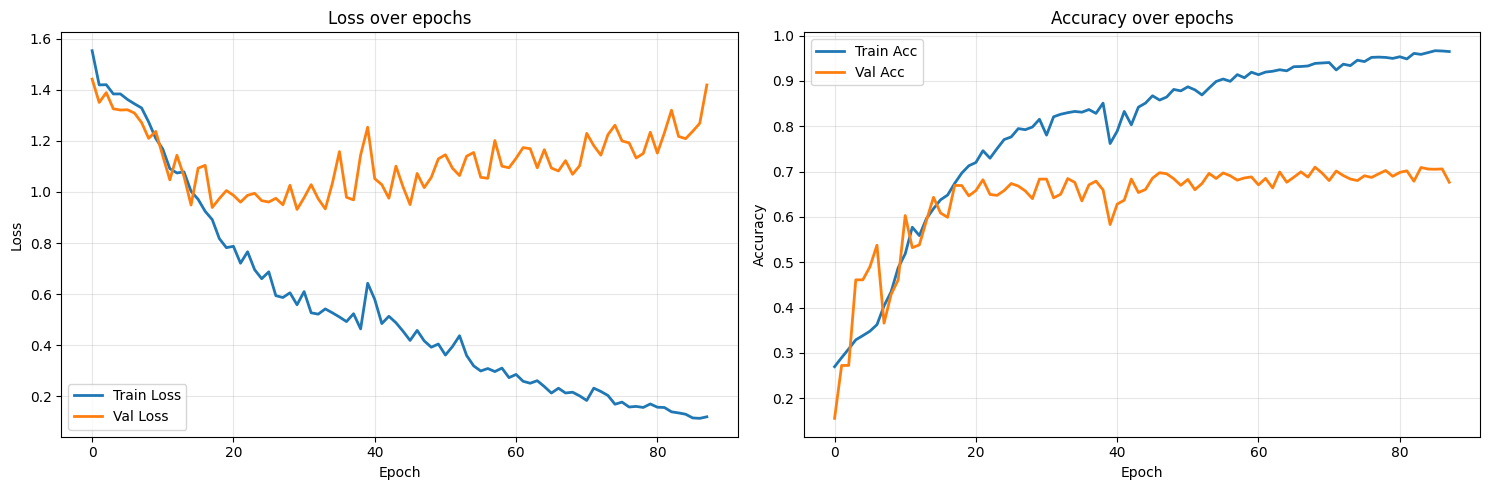


🔍 DIAGNOSTIC:
   ✅ BON ! Le modèle apprend
       → Peut-être besoin de plus d'epochs ou LR plus élevé



In [16]:
history, log_dir, best_val_f1,val_loader = training(config_ent, sleep_staging_model,base_data_path_emb, base_data_path, base_save_path, train_one_epoch, validate, criterion, checkpoint=False, checkpoint_path=checkpoint_path, plotter_bool=True)




📊 GÉNÉRATION MATRICE DE CONFUSION FINALE

🔄 Calcul des prédictions finales...


Validation: 100%|██████████| 1/1 [00:00<00:00,  4.82it/s]


✅ 4320 prédictions collectées

📊 Matrice de confusion (nombres absolus):
           Prédit →
   Vrai ↓    Wake     REM      N1      N2      N3
   --------------------------------------------------
   Wake      575      39      56       2       0
   REM        53       8      26       0       9
   N1        312      89    1378     180      33
   N2         45      16     339     774       2
   N3         44      41     112       0     187

📊 Matrice de confusion (pourcentages - Recall par classe):
           Prédit →
   Vrai ↓    Wake     REM      N1      N2      N3
   --------------------------------------------------
   Wake    85.6%    5.8%    8.3%    0.3%    0.0%
   REM     55.2%    8.3%   27.1%    0.0%    9.4%
   N1      15.7%    4.5%   69.2%    9.0%    1.7%
   N2       3.8%    1.4%   28.8%   65.8%    0.2%
   N3      11.5%   10.7%   29.2%    0.0%   48.7%

✅ Matrice de confusion sauvegardée: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\l

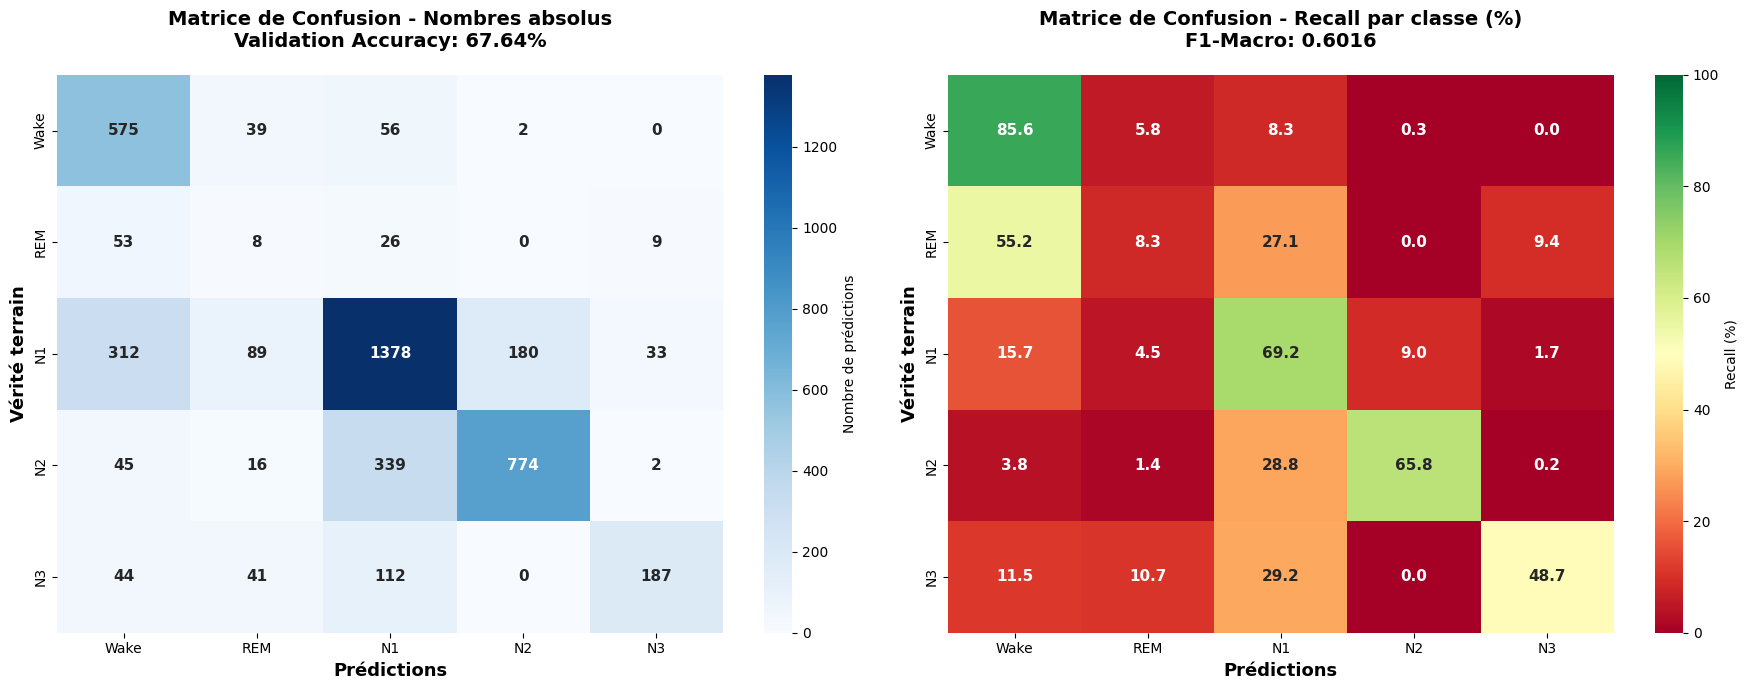


📈 MÉTRIQUES DÉTAILLÉES PAR CLASSE

Classe    Support  Precision     Recall   F1-Score
--------------------------------------------------
Wake          672      0.559      0.856      0.676
REM            96      0.041      0.083      0.055
N1           1992      0.721      0.692      0.706
N2           1176      0.810      0.658      0.726
N3            384      0.810      0.487      0.608
--------------------------------------------------
Macro                  0.588      0.555      0.554
Weighted               0.713      0.676      0.684

🔍 TOP 5 DES CONFUSIONS
  1.   339× N2   → N1   ( 28.8% des N2)
  2.   312× N1   → Wake ( 15.7% des N1)
  3.   180× N1   → N2   (  9.0% des N1)
  4.   112× N3   → N1   ( 29.2% des N3)
  5.    89× N1   → REM  (  4.5% des N1)



In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import os

def plot_final_confusion_matrix(sleep_staging_model, val_loader, device, log_dir, best_val_f1):
    """
    📊 Créer et sauvegarder la matrice de confusion finale
    """
    
    print("\n" + "="*60)
    print("📊 GÉNÉRATION MATRICE DE CONFUSION FINALE")
    print("="*60)
    
    # ============================================================
    # OBTENIR LES PRÉDICTIONS FINALES
    # ============================================================
    
    sleep_staging_model.eval()
    
    all_preds = []
    all_labels = []
    
    print("\n🔄 Calcul des prédictions finales...")
    
    with torch.no_grad():
        for x_batch, y_batch, mask_batch, paths in tqdm(val_loader, desc="Validation"):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask_batch = mask_batch.to(device)
            
            # Forward
            outputs = sleep_staging_model(x_batch, mask_batch)
            
            if isinstance(outputs, tuple):
                logits = outputs[0]
                mask_temporal = outputs[-1] if len(outputs) >= 2 else mask_batch[:, 0, :]
            else:
                logits = outputs
                mask_temporal = mask_batch[:, 0, :]
            
            # Prédictions
            preds = torch.argmax(logits, dim=-1)
            
            # Filtrer les éléments valides
            if mask_temporal.dtype == torch.bool:
                valid_idx = (~mask_temporal).cpu().numpy().flatten()
            else:
                valid_idx = (mask_temporal == 0).cpu().numpy().flatten()
            
            preds_flat = preds.cpu().numpy().flatten()
            labels_flat = y_batch.cpu().numpy().flatten()
            
            all_preds.extend(preds_flat[valid_idx])
            all_labels.extend(labels_flat[valid_idx])
    
    print(f"✅ {len(all_labels)} prédictions collectées")
    
    # ============================================================
    # CALCULER LA MATRICE DE CONFUSION
    # ============================================================
    
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3, 4])
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    stage_names = ['Wake', 'REM', 'N1', 'N2', 'N3']
    
    # ============================================================
    # AFFICHAGE TEXTUEL
    # ============================================================
    
    print(f"\n📊 Matrice de confusion (nombres absolus):")
    print(f"           Prédit →")
    print(f"   Vrai ↓  {'  '.join([f'{name:>6s}' for name in stage_names])}")
    print(f"   {'-'*50}")
    for i, name in enumerate(stage_names):
        row_str = '  '.join([f'{val:6d}' for val in cm[i]])
        print(f"   {name:4s}   {row_str}")
    
    print(f"\n📊 Matrice de confusion (pourcentages - Recall par classe):")
    print(f"           Prédit →")
    print(f"   Vrai ↓  {'  '.join([f'{name:>6s}' for name in stage_names])}")
    print(f"   {'-'*50}")
    for i, name in enumerate(stage_names):
        row_str = '  '.join([f'{val:5.1f}%' for val in cm_percent[i]])
        print(f"   {name:4s}   {row_str}")
    
    # ============================================================
    # VISUALISATION GRAPHIQUE
    # ============================================================
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Matrice 1 : Nombres absolus
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=stage_names, 
        yticklabels=stage_names,
        cbar_kws={'label': 'Nombre de prédictions'},
        ax=axes[0],
        annot_kws={'fontsize': 11, 'fontweight': 'bold'}
    )
    axes[0].set_xlabel('Prédictions', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Vérité terrain', fontsize=13, fontweight='bold')
    axes[0].set_title(
        f'Matrice de Confusion - Nombres absolus\nValidation Accuracy: {np.trace(cm)/cm.sum():.2%}', 
        fontsize=14, 
        fontweight='bold',
        pad=20
    )
    
    # Matrice 2 : Pourcentages (Recall)
    sns.heatmap(
        cm_percent, 
        annot=True, 
        fmt='.1f', 
        cmap='RdYlGn',
        xticklabels=stage_names, 
        yticklabels=stage_names,
        cbar_kws={'label': 'Recall (%)'},
        vmin=0, 
        vmax=100,
        ax=axes[1],
        annot_kws={'fontsize': 11, 'fontweight': 'bold'}
    )
    axes[1].set_xlabel('Prédictions', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Vérité terrain', fontsize=13, fontweight='bold')
    axes[1].set_title(
        f'Matrice de Confusion - Recall par classe (%)\nF1-Macro: {best_val_f1:.4f}', 
        fontsize=14, 
        fontweight='bold',
        pad=20
    )
    
    # Ajuster layout
    plt.tight_layout()
    
    # Sauvegarder
    save_path = os.path.join(log_dir, 'confusion_matrix_final.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    
    print(f"\n✅ Matrice de confusion sauvegardée: {save_path}")
    plt.show()
    
    # ============================================================
    # STATISTIQUES DÉTAILLÉES
    # ============================================================
    
    from sklearn.metrics import precision_recall_fscore_support
    
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, 
        labels=[0, 1, 2, 3, 4],
        zero_division=0
    )
    
    print(f"\n{'='*60}")
    print(f"📈 MÉTRIQUES DÉTAILLÉES PAR CLASSE")
    print(f"{'='*60}")
    print(f"\n{'Classe':<8s} {'Support':>8s} {'Precision':>10s} {'Recall':>10s} {'F1-Score':>10s}")
    print(f"{'-'*50}")
    
    for i, name in enumerate(stage_names):
        print(f"{name:<8s} {support[i]:>8d} {precision[i]:>10.3f} {recall[i]:>10.3f} {f1[i]:>10.3f}")
    
    print(f"{'-'*50}")
    print(f"{'Macro':8s} {'':<8s} {precision.mean():>10.3f} {recall.mean():>10.3f} {f1.mean():>10.3f}")
    print(f"{'Weighted':8s} {'':<8s} {np.average(precision, weights=support):>10.3f} {np.average(recall, weights=support):>10.3f} {np.average(f1, weights=support):>10.3f}")
    
    # ============================================================
    # ANALYSE DES ERREURS
    # ============================================================
    
    print(f"\n{'='*60}")
    print(f"🔍 TOP 5 DES CONFUSIONS")
    print(f"{'='*60}")
    
    # Trouver les confusions hors diagonale
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)
    
    confusions = []
    for i in range(5):
        for j in range(5):
            if i != j and cm[i, j] > 0:
                pct = cm[i, j] / cm[i].sum() * 100
                confusions.append((cm[i, j], pct, stage_names[i], stage_names[j]))
    
    confusions.sort(reverse=True)
    
    for rank, (count, pct, true_class, pred_class) in enumerate(confusions[:5], 1):
        print(f"  {rank}. {count:5d}× {true_class:4s} → {pred_class:4s} ({pct:5.1f}% des {true_class})")
    
    print(f"\n{'='*60}")
    
    return cm, cm_percent

cm, cm_percent = plot_final_confusion_matrix(
    sleep_staging_model=sleep_staging_model,
    val_loader=val_loader,
    device=device,
    log_dir=log_dir,
    best_val_f1=best_val_f1
)

In [18]:
print(os.getcwd())

c:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks


In [19]:
from utils import load_config, load_data, save_data, count_parameters

c:\Users\gabri\anaconda3\envs\sleepfm_env\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\gabri\AppData\Local\Temp\ipykernel_50880\1976399228.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `w


  Aucun checkpoint trouvé à C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\checkpoints\best.pth
   Le modèle sera entraîné depuis zéro
 Checkpoints: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\checkpoints
 Logs: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\logs

 Total de paires HDF5-CSV: 10

📊 Datasets créés:
   Train: 8 échantillons
   Val:   2 échantillons

🔍 Test d'alignement X/Y:
 Epoch 1/200



 Meilleur modèle sauvegardé (F1: 0.4285)
 Epoch 2/200



 Meilleur modèle sauvegardé (F1: 0.4584)
 Epoch 3/200



 Meilleur modèle sauvegardé (F1: 0.5026)
 Epoch 4/200


...

 Epoch 48/200


 Epoch 49/200


 Epoch 50/200


 Epoch 51/200



 Early stopping

 ENTRAÎNEMENT TERMINÉ
 Meilleur F1-Macro: 0.7155

✅ ENTRAÎNEMENT TERMINÉ

📈 Meilleur résultat:
   Val F1-Macro: 0.7155

📊 Progression:
   Epoch   1: Train Acc=0.300, Val Acc=0.650
   Epoch  50: Train Acc=0.968, Val Acc=0.777
   Epoch 100: Train Acc=0.964, Val Acc=0.784

✅ Graphiques sauvegardés: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\logs\overfit_curves.png


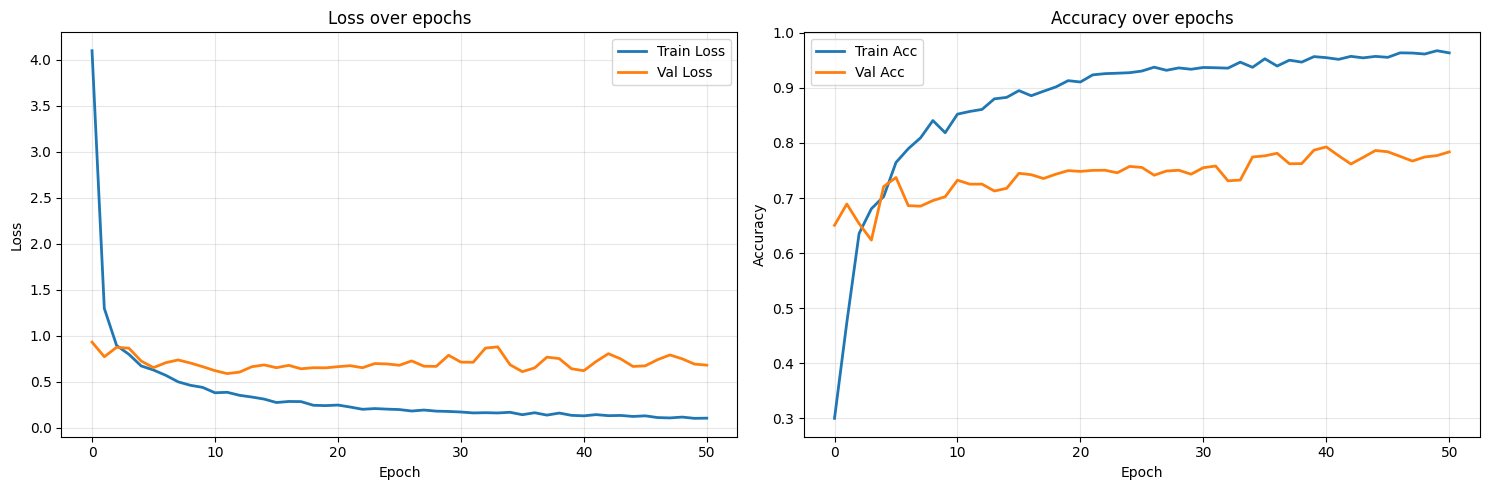


🔍 DIAGNOSTIC:
   ✅ BON ! Le modèle apprend
       → Peut-être besoin de plus d'epochs ou LR plus élevé



In [20]:
sleep_staging_model_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\sleepfm\\checkpoints\\model_sleep_staging"
sleep_staging_config = load_data(os.path.join(sleep_staging_model_path, "config.json"))
sleep_staging_model_params = sleep_staging_config['model_params']
sleep_staging_model_class = getattr(sys.modules[__name__], sleep_staging_config['model'])
sleep_staging_model2 = sleep_staging_model_class(**sleep_staging_model_params).to(device)
sleep_staging_model_name = type(sleep_staging_model2).__name__
sleep_staging_model2 = nn.DataParallel(sleep_staging_model2)
sleep_staging_checkpoint_path = os.path.join(sleep_staging_model_path, "best.pth")
sleep_staging_checkpoint = torch.load(sleep_staging_checkpoint_path)
sleep_staging_model2.load_state_dict(sleep_staging_checkpoint)

history, log_dir, best_val_f1,val_loader = training(config_ent, sleep_staging_model2,base_data_path_emb, base_data_path, base_save_path, train_one_epoch, validate, criterion, checkpoint=False, checkpoint_path=checkpoint_path, plotter_bool=True)



📊 GÉNÉRATION MATRICE DE CONFUSION FINALE

🔄 Calcul des prédictions finales...


Validation: 100%|██████████| 1/1 [00:00<00:00,  8.25it/s]

✅ 4320 prédictions collectées

📊 Matrice de confusion (nombres absolus):
           Prédit →
   Vrai ↓    Wake     REM      N1      N2      N3
   --------------------------------------------------
   Wake      648      13       8       3       0
   REM        49      40       7       0       0
   N1        158     132    1563      90      49
   N2         18       0     285     873       0
   N3          6       3     113       0     262

📊 Matrice de confusion (pourcentages - Recall par classe):
           Prédit →
   Vrai ↓    Wake     REM      N1      N2      N3
   --------------------------------------------------
   Wake    96.4%    1.9%    1.2%    0.4%    0.0%
   REM     51.0%   41.7%    7.3%    0.0%    0.0%
   N1       7.9%    6.6%   78.5%    4.5%    2.5%
   N2       1.5%    0.0%   24.2%   74.2%    0.0%
   N3       1.6%    0.8%   29.4%    0.0%   68.2%



✅ Matrice de confusion sauvegardée: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\logs\confusion_matrix_final.png


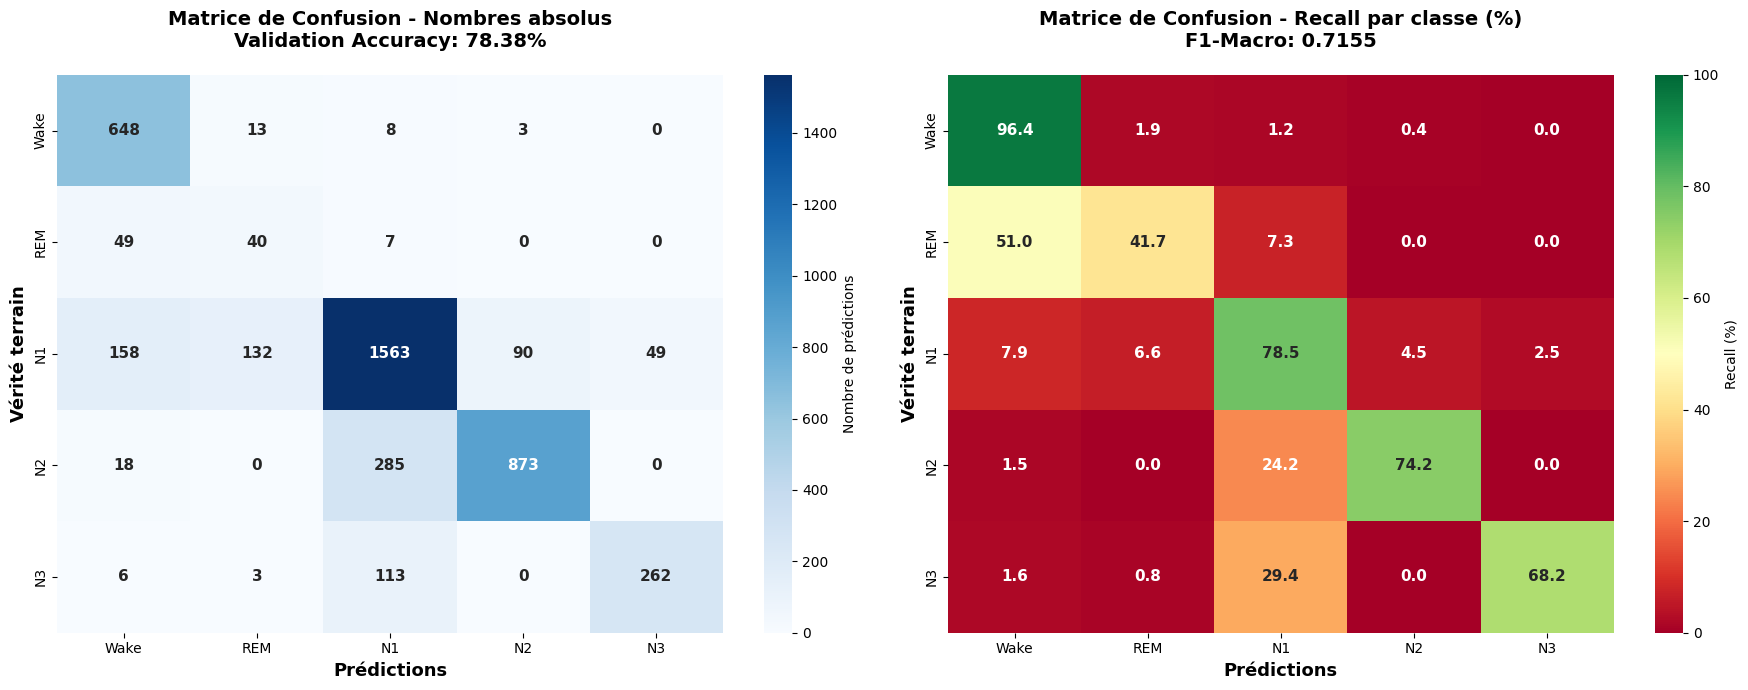


📈 MÉTRIQUES DÉTAILLÉES PAR CLASSE

Classe    Support  Precision     Recall   F1-Score
--------------------------------------------------
Wake          672      0.737      0.964      0.836
REM            96      0.213      0.417      0.282
N1           1992      0.791      0.785      0.788
N2           1176      0.904      0.742      0.815
N3            384      0.842      0.682      0.754
--------------------------------------------------
Macro                  0.697      0.718      0.695
Weighted               0.805      0.784      0.788

🔍 TOP 5 DES CONFUSIONS
  1.   285× N2   → N1   ( 24.2% des N2)
  2.   158× N1   → Wake (  7.9% des N1)
  3.   132× N1   → REM  (  6.6% des N1)
  4.   113× N3   → N1   ( 29.4% des N3)
  5.    90× N1   → N2   (  4.5% des N1)



In [21]:
cm, cm_percent = plot_final_confusion_matrix(
    sleep_staging_model=sleep_staging_model2,
    val_loader=val_loader,
    device=device,
    log_dir=log_dir,
    best_val_f1=best_val_f1
)

c:\Users\gabri\anaconda3\envs\sleepfm_env\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\gabri\AppData\Local\Temp\ipykernel_50880\749830329.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `we


  Aucun checkpoint trouvé à C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\checkpoints\best.pth
   Le modèle sera entraîné depuis zéro
 Checkpoints: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\checkpoints
 Logs: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\logs

 Total de paires HDF5-CSV: 10

📊 Datasets créés:
   Train: 8 échantillons
   Val:   2 échantillons

🔍 Test d'alignement X/Y:
 Epoch 1/200



 Meilleur modèle sauvegardé (F1: 0.1262)
 Epoch 2/200



 Meilleur modèle sauvegardé (F1: 0.1634)
 Epoch 3/200



 Meilleur modèle sauvegardé (F1: 0.3352)
 Epoch 4/200


...

 Epoch 43/200


 Epoch 44/200


 Epoch 45/200


 Epoch 46/200



 Early stopping

 ENTRAÎNEMENT TERMINÉ
 Meilleur F1-Macro: 0.6269

✅ ENTRAÎNEMENT TERMINÉ

📈 Meilleur résultat:
   Val F1-Macro: 0.6269

📊 Progression:
   Epoch   1: Train Acc=0.284, Val Acc=0.461
   Epoch 100: Train Acc=0.949, Val Acc=0.709

✅ Graphiques sauvegardés: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\logs\overfit_curves.png


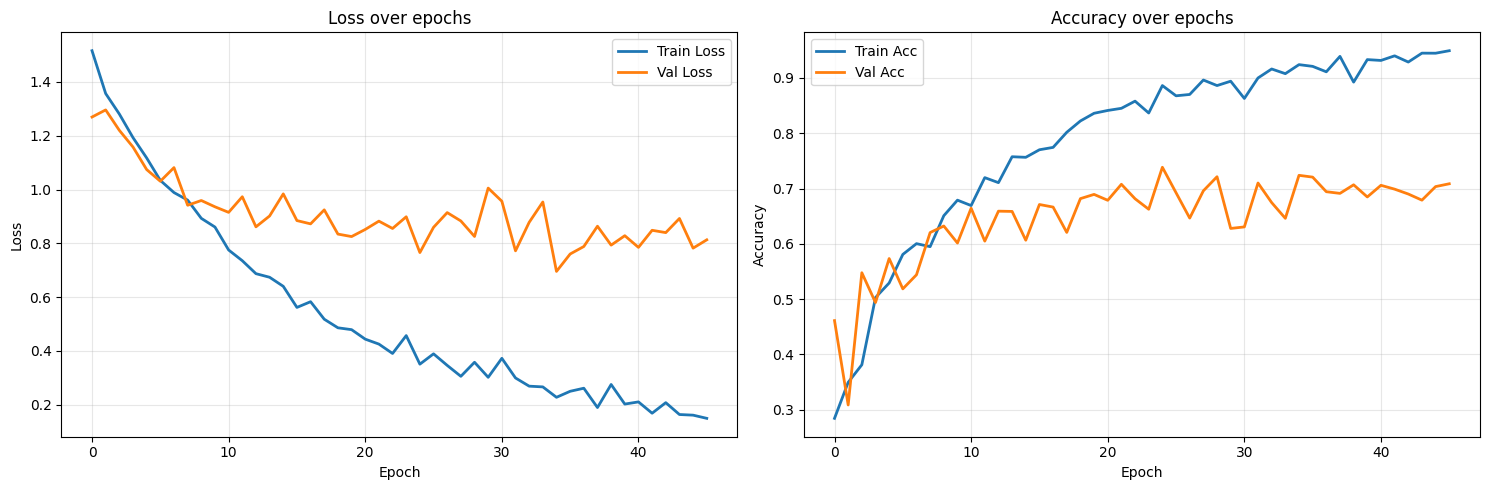


🔍 DIAGNOSTIC:
   ✅ BON ! Le modèle apprend
       → Peut-être besoin de plus d'epochs ou LR plus élevé



In [22]:
sleep_staging_model_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\sleepfm\\checkpoints\\model_sleep_staging"
sleep_staging_config = load_data(os.path.join(sleep_staging_model_path, "config.json"))
sleep_staging_model_params = sleep_staging_config['model_params']
sleep_staging_model_class = getattr(sys.modules[__name__], sleep_staging_config['model'])
sleep_staging_model3 = sleep_staging_model_class(**sleep_staging_model_params).to(device)
sleep_staging_model_name = type(sleep_staging_model3).__name__
sleep_staging_model3 = nn.DataParallel(sleep_staging_model3)
sleep_staging_checkpoint_path = os.path.join(sleep_staging_model_path, "best.pth")
sleep_staging_checkpoint = torch.load(sleep_staging_checkpoint_path)
"""sleep_staging_model2.load_state_dict(sleep_staging_checkpoint)"""

history, log_dir, best_val_f1,val_loader = training(config_ent, sleep_staging_model3,base_data_path_emb, base_data_path, base_save_path, train_one_epoch, validate, criterion, checkpoint=False, checkpoint_path=checkpoint_path, plotter_bool=True)



📊 GÉNÉRATION MATRICE DE CONFUSION FINALE

🔄 Calcul des prédictions finales...


Validation: 100%|██████████| 1/1 [00:00<00:00,  5.11it/s]


✅ 4320 prédictions collectées

📊 Matrice de confusion (nombres absolus):
           Prédit →
   Vrai ↓    Wake     REM      N1      N2      N3
   --------------------------------------------------
   Wake      571      21      78       2       0
   REM        40      13      43       0       0
   N1        154      11    1555     257      15
   N2          7       0     357     812       0
   N3          1       0     273       0     110

📊 Matrice de confusion (pourcentages - Recall par classe):
           Prédit →
   Vrai ↓    Wake     REM      N1      N2      N3
   --------------------------------------------------
   Wake    85.0%    3.1%   11.6%    0.3%    0.0%
   REM     41.7%   13.5%   44.8%    0.0%    0.0%
   N1       7.7%    0.6%   78.1%   12.9%    0.8%
   N2       0.6%    0.0%   30.4%   69.0%    0.0%
   N3       0.3%    0.0%   71.1%    0.0%   28.6%

✅ Matrice de confusion sauvegardée: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_10_data\l

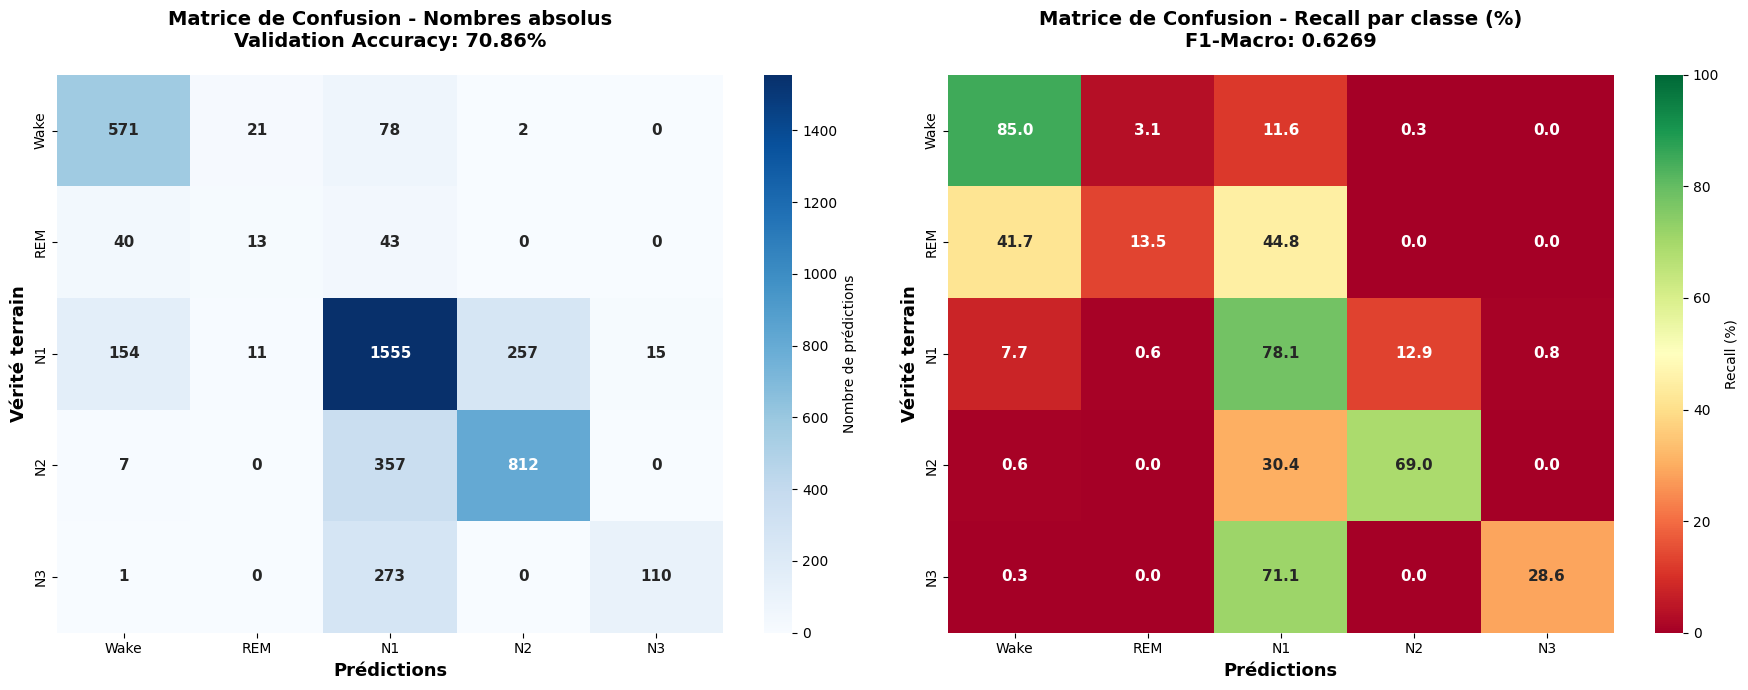


📈 MÉTRIQUES DÉTAILLÉES PAR CLASSE

Classe    Support  Precision     Recall   F1-Score
--------------------------------------------------
Wake          672      0.739      0.850      0.790
REM            96      0.289      0.135      0.184
N1           1992      0.674      0.781      0.724
N2           1176      0.758      0.690      0.723
N3            384      0.880      0.286      0.432
--------------------------------------------------
Macro                  0.668      0.549      0.571
Weighted               0.717      0.709      0.696

🔍 TOP 5 DES CONFUSIONS
  1.   357× N2   → N1   ( 30.4% des N2)
  2.   273× N3   → N1   ( 71.1% des N3)
  3.   257× N1   → N2   ( 12.9% des N1)
  4.   154× N1   → Wake (  7.7% des N1)
  5.    78× Wake → N1   ( 11.6% des Wake)



In [23]:
cm, cm_percent = plot_final_confusion_matrix(
    sleep_staging_model=sleep_staging_model3,
    val_loader=val_loader,
    device=device,
    log_dir=log_dir,
    best_val_f1=best_val_f1
)

verifier si les datas sont allignés avec les y
+ comprendre le decoupage

In [ ]:
def load_hdf5_to_raw(filepath):

    with h5py.File(filepath, 'r') as f:
        # Adapte ces clés selon ton fichier (inspecte avec f.keys())
        data = f['data'][:]          # shape: (n_channels, n_times)
        sfreq = f['sfreq'][()]
        ch_names = [name.decode() if isinstance(name, bytes) else name 
                    for name in f['ch_names'][:]]
        ch_types = [t.decode() if isinstance(t, bytes) else t 
                    for t in f['ch_types'][:]]

    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
    raw = mne.io.RawArray(data, info)
    return raw

def preprocess(filepath):
    raw = load_hdf5_to_raw(filepath)
    
    sfreq = raw.info["sfreq"]  # sfreq originale avant resample

    mne.set_bipolar_reference(
        raw, "EMG 1", "EMG 2", ch_name="EMG", copy=False
    )
    raw.set_channel_types({'EMG': 'emg'})
    mne.set_eeg_reference(raw, ["A2"], copy=False)
    raw.drop_channels(['A2'])

    raw.resample(128, npad="auto")
    raw.notch_filter([50])
    raw.filter(l_freq=0.3, h_freq=35, n_jobs=-1)

    return raw, sfreq
 

data = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_preproc"
edf_files = glob(os.path.join(data, "*.edf"))
for file in edf_files:
    filename = os.path.basename(file).replace('.edf', '')
    this_savepath = os.path.join(data, f"{filename}_preproc_raw.edf")
    raw = mne.io.read_raw_edf(file, include = CHANNEL_OI, preload = True)
    raw, sfreq = preprocess(raw)
    raw.save(this_savepath, overwrite=True)
    print(f"✅ Fichier prétraité et sauvegardé: {this_savepath}")

Extracting EDF parameters from C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\train_data_preproc\C1_001_PSG1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 11307519  =      0.000 ... 44169.996 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=11307520
    Range : 0 ... 11307519 =      0.000 ... 44169.996 secs
Ready.
Added the following bipolar channels:
EMG
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency:

[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    1.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   7 | elapsed:    3.5s remaining:    9.0s
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    3.7s remaining:    2.8s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    4.1s finished


OSError: The filename (C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\train_data_preproc\C1_001_PSG1_preproc_raw.edf) for file type raw must end with .fif or .fif.gz

: 

In [29]:
import mne
import numpy as np
from pathlib import Path

def preprocess(raw):
    """Pipeline de prétraitement"""
    mne.set_bipolar_reference(
        raw, "EMG 1", "EMG 2", ch_name="EMG", copy=False
    )
    raw.set_channel_types({'EMG': 'emg'})
    mne.set_eeg_reference(raw, ["A2"], copy=False)
    raw.drop_channels(['A2'])
    sfreq = raw.info["sfreq"]
    raw.resample(128, npad="auto")
    raw.notch_filter([50])
    raw.filter(l_freq=0.3, h_freq=35, n_jobs=-1)
    return raw, sfreq

def remove_high_amplitude(raw, threshold=500e-6):
    """Rejeter les segments avec amplitude EEG > threshold"""
    eeg_picks = mne.pick_types(raw.info, eeg=True)
    data = raw.get_data(picks=eeg_picks)
    bad_segments = []
    times = raw.times
    
    for i, sample in enumerate(data.T):
        if np.any(np.abs(sample) > threshold):
            bad_segments.append(times[i])
    
    if bad_segments:
        onset = bad_segments
        duration = [1.0 / raw.info['sfreq']] * len(bad_segments)
        description = ['BAD_amplitude'] * len(bad_segments)
        annotations = mne.Annotations(onset, duration, description)
        raw.set_annotations(raw.annotations + annotations)
    
    return raw

def process_multiple_edf(edf_files, output_dir="processed", save_format='edf', CHANNEL_OI = ['EMG']):
    Path(output_dir).mkdir(exist_ok=True)
    
    for edf_file in edf_files:
        print(f"\n📂 Traitement de : {edf_file}")
        
        # Charger
        raw = mne.io.read_raw_edf(edf_file,include = CHANNEL_OI, preload=True)
        
        # Prétraitement
        raw, sfreq_original = preprocess(raw)
        
        # Rejeter amplitudes > 500µV
        raw = remove_high_amplitude(raw, threshold=500e-6)
        
        # Nom de sortie : nom_original_preprocessed.ext
        original_name = Path(edf_file).stem  # nom sans extension
        
        if save_format == 'edf':
            output_file = Path(output_dir) / f"{original_name}_preprocessed.edf"
            mne.export.export_raw(output_file, raw, fmt='edf', overwrite=True)
        
        print(f"✅ Sauvegardé : {output_file}")

data = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_preproc"
edf_files = glob(os.path.join(data, "*.edf"))
print(edf_files)

CHANNEL_GROUPS = {
    "EEG": ["Fp1", "C3", "O1","C4"],       
    "EOG": ["EOG G", "EOG D"],
    "EMG": ["EMG 1", "EMG 2"],          
    "ECG": ["ECG"],
    "REF": ["A2"],                      
}

# liste plate pour include=
CHANNEL_OI = sorted({ch for grp in CHANNEL_GROUPS.values() for ch in grp})
process_multiple_edf(edf_files, output_dir="processed", save_format='edf', CHANNEL_OI=CHANNEL_OI)



['C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_preproc\\C1_001_PSG1.edf', 'C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_preproc\\C1_002_PSG1.edf', 'C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_preproc\\C1_003_PSG1.edf', 'C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_preproc\\C1_004_PSG1.edf', 'C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_preproc\\C1_005_PSG1.edf', 'C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_preproc\\C1_006_PSG1.edf', 'C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_preproc\\C1_007_PSG1.edf', 'C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data_preproc\\C1_008_PS

[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    3.0s finished


Setting up band-pass filter from 0.3 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.30 Hz (-6 dB cutoff frequency: 0.15 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 1409 samples (11.008 s)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   7 | elapsed:    4.0s remaining:   10.1s
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    4.2s remaining:    3.2s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    4.6s finished


RuntimeError: For exporting to EDF to work, the edfio module is needed, but it could not be imported.
              use the following installation method appropriate for your environment:
              'pip install edfio'
              'conda install -c conda-forge edfio'

In [ ]:
output = os.path.join(hdf5_paths, "train_emb_preprocess")
output_5min_agg = os.path.join(hdf5_paths, "train_emb_5min_agg_preprocess")
create_embedding_and_filtering(config, hdf5_paths, collate_fn, output, output_5min_agg, checkpoint = True)